In [8]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

PATH = "biomni/data/biomni_data/data_lake/amplicon_data/CCLE.csv"
df = pd.read_csv(PATH)

# Keep only rows that are real amplicon features (Classification present)
df_feat = df[df["Classification"].notna()].copy()

# ---- helpers to parse list-like columns safely ----
def _parse_list_cell(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        raw = x
    else:
        try:
            raw = ast.literal_eval(str(x))
        except Exception:
            return []
    if not isinstance(raw, list):
        return []
    out = []
    for item in raw:
        s = str(item).strip()
        s = s.strip("'").strip('"').strip()
        if s and s.lower() != "nan":
            out.append(s)
    return out

df_feat["oncogenes_list"] = df_feat["Oncogenes"].apply(_parse_list_cell)
df_feat["all_genes_list"] = df_feat["All genes"].apply(_parse_list_cell)

# numeric columns (coerce)
num_cols = [
    "Captured interval length",
    "Feature median copy number",
    "Feature maximum copy number",
    "Complexity score",
]
for c in num_cols:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")

print("Rows:", df.shape, "Feature-rows:", df_feat.shape)
print("Classifications:", df_feat["Classification"].value_counts().to_dict())


Rows: (1234, 30) Feature-rows: (1157, 32)
Classifications: {'Linear': 550, 'ecDNA': 297, 'Complex-non-cyclic': 196, 'BFB': 114}


# 1)List me all samples that YES1 is amplified as ecDNA or BFB in CCLE? only return sample names and classification and feautre ID and location.

In [11]:
gene = "YES1"

hits = df_feat[
    df_feat["oncogenes_list"].apply(lambda xs: gene in xs)
    | df_feat["all_genes_list"].apply(lambda xs: gene in xs)
].copy()

summary = (
    hits.groupby("Classification")["Sample name"]
    .nunique()
    .sort_values(ascending=False)
)

print("Unique samples with YES1 amplification by class:")
print(summary)

print("\nExample rows (sample, class, feature, locus):")
cols = ["Sample name", "Classification", "Feature ID", "Location"]
print(hits[cols].sort_values(["Classification","Sample name"]).head(30).to_string(index=False))
print('Standard answer format:')
result = hits[cols].to_dict("records")
print(result)


Unique samples with YES1 amplification by class:
Classification
BFB    1
Name: Sample name, dtype: int64

Example rows (sample, class, feature, locus):
      Sample name Classification                        Feature ID                   Location
KYSE70_OESOPHAGUS            BFB KYSE70_OESOPHAGUS_amplicon7_BFB_1 ["'chr18:634973-4361110'"]
Standard answer format:
[{'Sample name': 'KYSE70_OESOPHAGUS', 'Classification': 'BFB', 'Feature ID': 'KYSE70_OESOPHAGUS_amplicon7_BFB_1', 'Location': '["\'chr18:634973-4361110\'"]'}]


# 2)Compute summary statistics for the captured interval length of all BFB amplifications, including mean, standard deviation, minimum, maximum, and the 10th–90th percentiles.

BFB count: 114 with size: 114
count    1.140000e+02
mean     2.271737e+06
std      2.991727e+06
min      5.946300e+04
10%      2.033848e+05
25%      5.037368e+05
50%      1.276367e+06
75%      2.929109e+06
90%      5.312285e+06
max      2.124683e+07
Name: Captured interval length, dtype: float64
Standard answer format:
{'mean': 2271736.6315789474, 'std': 2991727.3123322204, 'min': 59463.0, 'max': 21246834.0, 'p10': 203384.80000000002, 'p20': 407800.4, 'p30': 562176.2, 'p40': 754368.2000000001, 'p50': 1276367.0, 'p60': 1784387.4, 'p70': 2257390.1, 'p80': 3535639.6000000006, 'p90': 5312285.4}


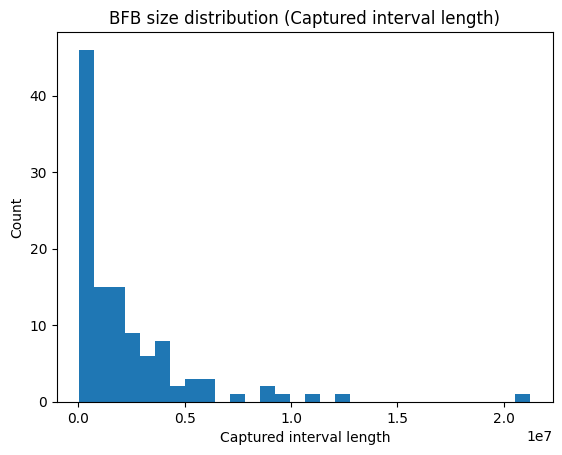

In [12]:
bfb = df_feat[df_feat["Classification"].eq("BFB")].copy()
sizes = bfb["Captured interval length"].dropna()

print("BFB count:", len(bfb), "with size:", sizes.notna().sum())
print(sizes.describe(percentiles=[0.1,0.25,0.5,0.75,0.9]))

print('Standard answer format:')
result = {
    "mean": float(sizes.mean()),
    "std": float(sizes.std()),
    "min": float(sizes.min()),
    "max": float(sizes.max()),
}

# add percentiles 10–90
for p in range(10, 100, 10):
    result[f"p{p}"] = float(np.percentile(sizes, p))

print(result)


plt.figure()
plt.hist(sizes, bins=30)
plt.xlabel("Captured interval length")
plt.ylabel("Count")
plt.title("BFB size distribution (Captured interval length)")
plt.show()


# 3)List all BFB amplification features in the HARA sample and report the following fields: feature ID, genomic locus, genes, and maximum copy number.

In [ ]:
sample = "HARA_LUNG"
bt = df_feat[(df_feat["Sample name"] == sample) & (df_feat["Classification"] == "BFB")].copy()

cols = [
    "Sample name","Classification","AA amplicon number","Feature ID","Location","All genes","Feature maximum copy number"
]
print("BFB features in", sample, ":", len(bt))
print(bt[cols].sort_values(["AA amplicon number","Feature ID"]).to_string(index=False))
result = bt.to_dict("records")
print(result)

BFB features in HARA_LUNG : 1
Sample name Classification  AA amplicon number                Feature ID                                                   Location  Captured interval length  Feature median copy number  Feature maximum copy number   Oncogenes                                                                                                                                                                              All genes
  HARA_LUNG            BFB                 6.0 HARA_LUNG_amplicon6_BFB_1 ["'chr11:34893970-37730986'", "'chr11:37761005-41072281'"]                 6148292.0                   15.180671                    56.560276 ["'TRAF6'"] ["'APIP'", "'C11orf74'", "'CD44'", "'COMMD9'", "'FJX1'", "'LDLRAD3'", "'LRRC4C'", "'PAMR1'", "'PDHX'", "'PRR5L'", "'RAG1'", "'RAG2'", "'SLC1A2'", "'SNORD164'", "'TRAF6'", "'TRIM44'"]
[{'Unnamed: 0': 285, 'Sample name': 'HARA_LUNG', 'AA amplicon number': 6.0, 'Feature ID': 'HARA_LUNG_amplicon6_BFB_1', 'Classification': 'BFB', 'Locat

# 4) Which genes are most frequently amplified as BFB? (top 25)

In [297]:
from collections import Counter

bfb = df_feat[df_feat["Classification"].eq("BFB")].copy()

ctr = Counter()
for genes in bfb["oncogenes_list"]:
    ctr.update(set(genes))  # set() to avoid double-counting within one feature

top = pd.DataFrame(ctr.most_common(25), columns=["Gene","BFB_feature_count"])
print(top.to_string(index=False))

 Gene  BFB_feature_count
 CTTN                  5
 MYCL                  4
CCND1                  4
 FGF3                  4
 FGF4                  4
TRAF6                  3
MMP12                  3
BIRC3                  3
BIRC2                  3
 YAP1                  3
MIEN1                  3
CDK12                  3
ERBB2                  3
 LDHB                  2
CCNE1                  2
 URI1                  2
 AKT2                  2
ACTN4                  2
 CRKL                  2
  MYC                  2
 PVT1                  2
  KDR                  2
  KIT                  2
MLLT6                  2
LASP1                  2


# 5) Show the distribution of amplification classes across cancer types (Tissue of origin)

Classification                      BFB  Complex-non-cyclic  Linear  ecDNA
Tissue of origin                                                          
autonomic ganglia                     0                   0       0      1
bone                                  1                   0       1      0
breast                               13                  32     101     62
central nervous system                0                   5       7      6
endometrium                           2                   5      14     12
haematopoietic and lymphoid tissue    0                   5      18      5
kidney                                2                   0       3      2
large intestine                       3                   7      12      4
liver                                 4                   8       8      5
lung                                 43                  67     193    104
oesophagus                           11                  12      40     21
ovary                    

<Figure size 640x480 with 0 Axes>

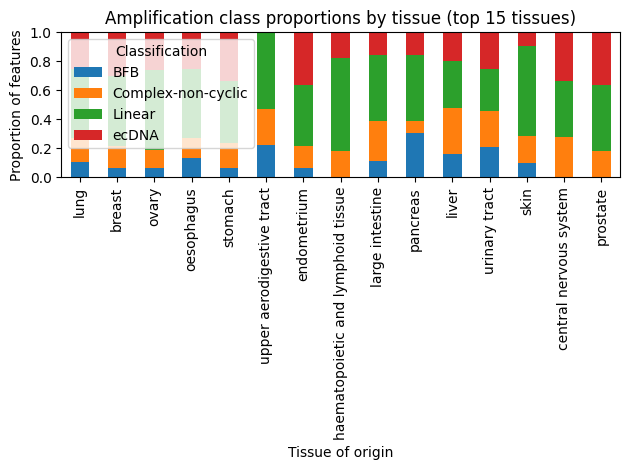

In [298]:
tab = pd.crosstab(df_feat["Tissue of origin"], df_feat["Classification"]).sort_index()
print(tab.head(20))

# Also show proportions per tissue
prop = tab.div(tab.sum(axis=1), axis=0).fillna(0)
print("\nProportions (first 20 tissues):")
print(prop.head(20))

# Plot top tissues by total feature count
top_tissues = tab.sum(axis=1).sort_values(ascending=False).head(15).index
plt.figure()
prop.loc[top_tissues].plot(kind="bar", stacked=True)
plt.ylabel("Proportion of features")
plt.title("Amplification class proportions by tissue (top 15 tissues)")
plt.tight_layout()
plt.show()


# 6) For each tissue, what fraction of samples have any ecDNA?

Top 25 tissues by ecDNA-sample fraction:
Tissue of origin
autonomic ganglia                     1.000000
thyroid                               1.000000
oesophagus                            1.000000
ovary                                 0.882353
breast                                0.787879
lung                                  0.670455
stomach                               0.631579
central nervous system                0.625000
endometrium                           0.600000
prostate                              0.500000
haematopoietic and lymphoid tissue    0.500000
large intestine                       0.500000
liver                                 0.500000
pleura                                0.500000
urinary tract                         0.428571
kidney                                0.400000
pancreas                              0.375000
skin                                  0.166667
soft tissue                           0.000000
bone                                  0.000000
up

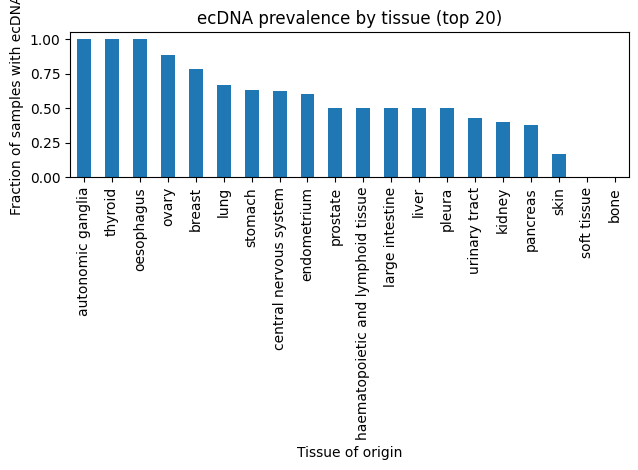

In [299]:
# sample-level: does a sample have >=1 ecDNA feature?
sample_has_ec = (
    df_feat.assign(has_ecDNA=df_feat["Classification"].eq("ecDNA"))
          .groupby(["Tissue of origin","Sample name"])["has_ecDNA"]
          .any()
          .reset_index()
)

tissue_frac = (
    sample_has_ec.groupby("Tissue of origin")["has_ecDNA"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 25 tissues by ecDNA-sample fraction:")
print(tissue_frac.head(25))

plt.figure()
tissue_frac.head(20).plot(kind="bar")
plt.ylabel("Fraction of samples with ecDNA")
plt.title("ecDNA prevalence by tissue (top 20)")
plt.tight_layout()
plt.show()


# 7) Do Complexity scores differ between ecDNA vs BFB vs Linear vs Complex-non-cyclic?

                    count      mean       std       min       25%       50%  \
Classification                                                                
BFB                 114.0  1.063654  0.256257  0.474421  0.887858  1.021014   
Complex-non-cyclic  196.0  1.261700  0.448434  0.222816  0.921391  1.189101   
Linear              550.0  0.580827  0.366532  0.000000  0.376822  0.636480   
ecDNA               297.0  0.840714  0.394129  0.133345  0.601398  0.686838   

                         75%       max  
Classification                          
BFB                 1.218679  1.758271  
Complex-non-cyclic  1.533952  2.660781  
Linear              0.810626  1.845296  
ecDNA               1.012470  2.357014  


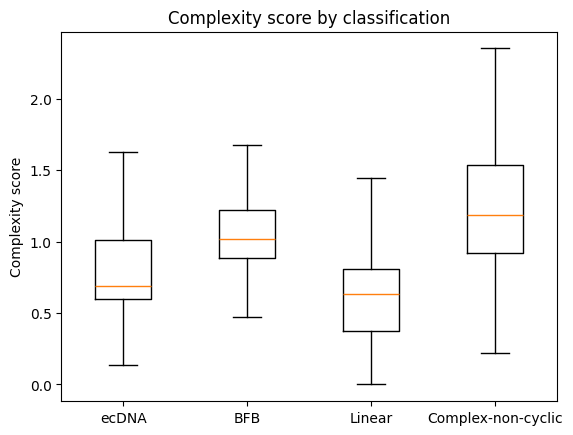

In [300]:
x = df_feat[["Classification","Complexity score"]].dropna().copy()

stats = x.groupby("Classification")["Complexity score"].describe(percentiles=[0.25,0.5,0.75])
print(stats)

# simple boxplot (matplotlib)
classes = ["ecDNA","BFB","Linear","Complex-non-cyclic"]
data = [x.loc[x["Classification"].eq(c),"Complexity score"].values for c in classes if c in x["Classification"].unique()]

plt.figure()
plt.boxplot(data, tick_labels=[c for c in classes if c in x["Classification"].unique()], showfliers=False)
plt.ylabel("Complexity score")
plt.title("Complexity score by classification")
plt.show()
    

# 8) For ecDNA vs BFB, how does size relate to max copy number? (scatter + correlation)

ecDNA: n=297 corr(size, maxCN)=0.0498
BFB: n=114 corr(size, maxCN)=-0.0029


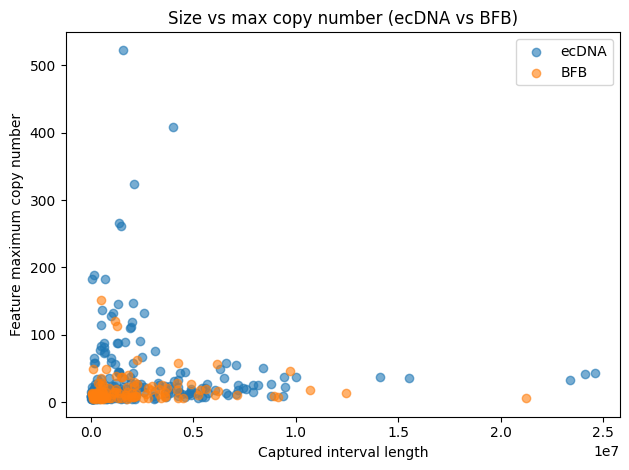

In [301]:
sub = df_feat[df_feat["Classification"].isin(["ecDNA","BFB"])].copy()
sub = sub.dropna(subset=["Captured interval length","Feature maximum copy number"])

# correlations per class
for cls in ["ecDNA","BFB"]:
    s = sub[sub["Classification"] == cls]
    corr = s["Captured interval length"].corr(s["Feature maximum copy number"])
    print(f"{cls}: n={len(s)} corr(size, maxCN)={corr:.4f}")

# scatter
plt.figure()
for cls in ["ecDNA","BFB"]:
    s = sub[sub["Classification"] == cls]
    plt.scatter(s["Captured interval length"], s["Feature maximum copy number"], label=cls, alpha=0.6)
plt.xlabel("Captured interval length")
plt.ylabel("Feature maximum copy number")
plt.title("Size vs max copy number (ecDNA vs BFB)")
plt.legend()
plt.tight_layout()
plt.show()


# 9) What are the highest copy-number amplifications in CCLE? (top 5)

In [302]:
top = (
    df_feat.dropna(subset=["Feature maximum copy number"])
          .sort_values("Feature maximum copy number", ascending=False)
          .head(5)
)

cols = ["Sample name","Tissue of origin","Classification","Feature ID","Location",
        "Feature maximum copy number","Feature median copy number","Captured interval length","Oncogenes"]
print(top[cols].to_string(index=False))


    Sample name Tissue of origin Classification                        Feature ID                                                                                                                                                                                                                                                                                                                                                                             Location  Feature maximum copy number  Feature median copy number  Captured interval length                                                     Oncogenes
   NCIH524_LUNG             lung          ecDNA    NCIH524_LUNG_amplicon2_ecDNA_1                                                                                                                                                                                                                                                                                           ["'chr8:120528251-120544068'", "'chr

# 10) Which oncogenes appear in both ecDNA and BFB across CCLE?

In [303]:
from collections import defaultdict

gene_classes = defaultdict(set)

for _, r in df_feat.iterrows():
    for g in r["oncogenes_list"]:
        gene_classes[g].add(r["Classification"])

both = sorted([g for g, cls in gene_classes.items() if {"ecDNA","BFB"} <= cls])

print("Genes appearing in both ecDNA and BFB:")
print(both)
print("Count:", len(both))


Genes appearing in both ecDNA and BFB:
['ARID2', 'ARNT', 'BIRC2', 'BIRC3', 'BRF2', 'CAV1', 'CCND1', 'CCND3', 'CCNE1', 'CDK12', 'CHIC2', 'COPS3', 'CSF3', 'CSF3R', 'CTTN', 'EGFR', 'EMSY', 'ERBB2', 'FGF3', 'FGF4', 'FIP1L1', 'FOXA1', 'FOXG1', 'GAB2', 'INTS3', 'INTS4', 'KDR', 'KIT', 'KRAS', 'LASP1', 'LDHB', 'MCL1', 'MDM2', 'MECOM', 'MET', 'MIEN1', 'MLANA', 'MLLT11', 'MLLT6', 'MMP12', 'MPL', 'MYC', 'MYCL', 'NKX2-1', 'PAK1', 'PDGFRA', 'PRKCI', 'PRMT5', 'PVT1', 'RPL23', 'RSF1', 'SEC62', 'SETDB1', 'SFPQ', 'SKIL', 'SMURF1', 'SREBF1', 'TFEB', 'THRA', 'THRAP3', 'TRAF6', 'TRIO', 'URI1', 'WNT2', 'YAP1', 'YEATS4', 'ZNF703']
Count: 67


# 12) Which samples contain both ecDNA and BFB amplifications?

In [304]:
sample_classes = (
    df_feat.groupby("Sample name")["Classification"]
    .apply(set)
)

both = sample_classes[sample_classes.apply(lambda x: {"ecDNA","BFB"} <= x)]
print("Samples with both ecDNA and BFB:")
print(both.index.tolist())
print("Count:", len(both))


Samples with both ecDNA and BFB:
['ABC1_LUNG', 'AU565_BREAST', 'BT20_BREAST', 'CHAGOK1_LUNG', 'CORL88_LUNG', 'COV644_OVARY', 'DANG_PANCREAS', 'DMS114_LUNG', 'DMS273_LUNG', 'EBC1_LUNG', 'EFM19_BREAST', 'HARA_LUNG', 'HCC1500_BREAST', 'HCC1599_BREAST', 'HCC1954_BREAST', 'HCC38_BREAST', 'HCC827_LUNG', 'HCC95_LUNG', 'JHH7_LIVER', 'KLE_ENDOMETRIUM', 'KYSE180_OESOPHAGUS', 'KYSE30_OESOPHAGUS', 'KYSE410_OESOPHAGUS', 'KYSE70_OESOPHAGUS', 'MDAMB157_BREAST', 'MDAMB175VII_BREAST', 'MDAMB453_BREAST', 'MKN1_STOMACH', 'MKN74_STOMACH', 'NCIH1092_LUNG', 'NCIH1435_LUNG', 'NCIH1651_LUNG', 'NCIH1694_LUNG', 'NCIH1792_LUNG', 'NCIH1876_LUNG', 'NCIH2029_LUNG', 'NCIH2066_LUNG', 'NCIH2170_LUNG', 'NCIH2171_LUNG', 'NCIH3255_LUNG', 'NCIH520_LUNG', 'NCIH650_LUNG', 'NCIH661_LUNG', 'NCIH889_LUNG', 'NIHOVCAR3_OVARY', 'OE19_OESOPHAGUS', 'OV90_OVARY', 'RMGI_OVARY', 'SCABER_URINARY_TRACT', 'SNU182_LIVER', 'TE11_OESOPHAGUS']
Count: 51


# 13) Are ecDNA amplifications larger than BFB on average?

In [305]:
sizes = (
    df_feat[df_feat["Classification"].isin(["ecDNA","BFB"])]
    .groupby("Classification")["Captured interval length"]
    .describe()
)

print(sizes)


                count          mean           std      min        25%  \
Classification                                                          
BFB             114.0  2.271737e+06  2.991727e+06  59463.0  503736.75   
ecDNA           297.0  2.096639e+06  3.299880e+06  10387.0  260748.00   

                      50%         75%         max  
Classification                                     
BFB             1276367.0  2929108.75  21246834.0  
ecDNA            985738.0  2233311.00  24593843.0  


# 14) Which samples have high-copy (>20 CN) ecDNA?

In [306]:
hc = df_feat[
    (df_feat["Classification"] == "ecDNA") &
    (df_feat["Feature maximum copy number"] > 20)
]

print(hc[["Sample name","Location","Feature maximum copy number","Oncogenes"]])


                                  Sample name  \
2                          5637_URINARY_TRACT   
5                                   59M_OVARY   
12                              8305C_THYROID   
35                               AU565_BREAST   
55                               BT474_BREAST   
...                                       ...   
1148                             SNU475_LIVER   
1155            SW1783_CENTRAL_NERVOUS_SYSTEM   
1199  THP1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE   
1212                           UACC812_BREAST   
1219                           UACC893_BREAST   

                                               Location  \
2                          ["'chr6:20350615-22839372'"]   
5     ["'chr8:52712046-56014576'", "'chr8:65533018-6...   
12    ["'chr20:34283685-34285398'", "'chr20:34299250...   
35    ["'chr8:71754758-71754831'", "'chr8:71755523-7...   
55    ["'chr20:44404279-45225559'", "'chr20:49762732...   
...                                                 ...  

# 15) What is the largest amplicon (by size) per class?

In [307]:
largest = (
    df_feat.sort_values("Captured interval length", ascending=False)
    .groupby("Classification")
    .head(1)
)

cols = ["Classification","Sample name","Location","Captured interval length","Oncogenes"]
print(largest[cols].to_string(index=False))


    Classification                     Sample name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

# 16) Which tissues show highest amplification complexity (median)?

In [308]:
tissue_complexity = (
    df_feat.groupby("Tissue of origin")["Complexity score"]
    .median()
    .sort_values(ascending=False)
)

print(tissue_complexity.head(20))


Tissue of origin
pleura                                1.248873
autonomic ganglia                     1.176241
soft tissue                           1.129679
liver                                 0.973848
large intestine                       0.961082
kidney                                0.872199
urinary tract                         0.869917
pancreas                              0.840527
skin                                  0.810184
upper aerodigestive tract             0.807988
stomach                               0.788245
central nervous system                0.759224
lung                                  0.719535
ovary                                 0.691793
oesophagus                            0.688151
haematopoietic and lymphoid tissue    0.681421
breast                                0.681368
endometrium                           0.676187
prostate                              0.664281
thyroid                               0.591204
Name: Complexity score, dtype: float64


# 17) For a given gene, list all co-amplified genes (same feature)

In [309]:
gene = "EGFR"

co = set()
for _, r in df_feat.iterrows():
    if gene in r["all_genes_list"]:
        co |= set(r["all_genes_list"])

co.discard(gene)
print("Co-amplified genes with", gene)
print(sorted(co))


Co-amplified genes with EGFR
['CALN1', 'CCT6A', 'COBL', 'DDC', 'DDC-AS1', 'EGFR-AS1', 'ELDR', 'FIGNL1', 'FKBP9P1', 'GRB10', 'IKZF1', 'LANCL2', 'MRPS17', 'NIPSNAP2', 'POM121L12', 'PSPH', 'SEC61G', 'SEPTIN14', 'SPATA48', 'UBE2J2', 'VOPP1', 'VSTM2A', 'VSTM2A-OT1', 'ZNF713', 'ZPBP']


# 18) Which genes are exclusive to ecDNA (never BFB or Linear)?

In [310]:
gene_cls = defaultdict(set)

for _, r in df_feat.iterrows():
    for g in r["oncogenes_list"]:
        gene_cls[g].add(r["Classification"])

exclusive = sorted([g for g,c in gene_cls.items() if c == {"ecDNA"}])
print("ecDNA-exclusive genes:", exclusive)


ecDNA-exclusive genes: ['AHI1', 'AKTIP', 'ARAF', 'ATM', 'BAALC', 'BCAR4', 'BCL7A', 'BMI1', 'CAD', 'CARD11', 'CBLL1', 'CD24', 'CIITA', 'COPS5', 'COX6C', 'CSNK2A1', 'CTNNB1', 'DDHD2', 'DDX10', 'DDX6', 'DUSP26', 'EIF3E', 'ELK1', 'FGFR2', 'FUS', 'FZD2', 'GNA12', 'GOPC', 'HEY1', 'HMGA2', 'IFNG', 'IGF2BP1', 'IKZF1', 'JUN', 'JUP', 'KMT2A', 'KSR2', 'LSM1', 'MALT1', 'MAML2', 'MAP2K4', 'MAP3K8', 'MNAT1', 'MSI2', 'MTDH', 'MYB', 'MYCN', 'NANOG', 'NCOA3', 'NME1', 'OTX2', 'PAX8', 'PBX1', 'PICALM', 'RAD51B', 'RARA', 'RB1', 'RMI2', 'RNF217-AS1', 'RNF43', 'ROS1', 'RUNX1T1', 'SALL4', 'SGK1', 'SIX1', 'SOCS1', 'SS18L1', 'SUFU', 'TACSTD2', 'TBC1D15', 'TCEA1', 'TPD52', 'TREH', 'TRIB2', 'TRIM8', 'UBR5', 'VTI1A', 'WWTR1']


# 19) Which chromosomes are most frequently amplified?

In [311]:
chroms = (
    df_feat["Location"]
    .str.extract(r"(chr\d+|chrX|chrY)", expand=False)
)

chrom_counts = chroms.value_counts()
print(chrom_counts)


Location
chr1     122
chr8     104
chr11    101
chr3      77
chr12     74
chr6      62
chr17     62
chr7      55
chr2      54
chr20     48
chr5      44
chr14     42
chr19     38
chr16     34
chrX      34
chr4      33
chr9      31
chr10     31
chr22     29
chr18     25
chr13     24
chr15     21
chr21     11
Name: count, dtype: int64


# 20) Which oncogenes are most recurrent across unique samples (any class)?

In [312]:
pairs = []
for _, r in df_feat.iterrows():
    for g in set(r["oncogenes_list"]):
        pairs.append((g, r["Sample name"]))

pairs = pd.DataFrame(pairs, columns=["Gene","Sample"])

top = (
    pairs.drop_duplicates()
    .groupby("Gene")["Sample"]
    .nunique()
    .sort_values(ascending=False)
)

print(top.head(30))


Gene
PVT1      33
MYC       33
CTTN      23
FGF4      23
CCND1     23
FGF3      23
MIEN1     19
ERBB2     19
MYCL      17
CDK12     15
KDM2A     12
URI1      11
KRAS      11
MECOM     10
CRKL      10
MUC4       9
FGFR1      8
CCNE1      8
YAP1       8
BRF2       8
NSD3       8
SEC62      7
MMP12      7
BIRC3      7
BIRC2      7
NKX2-1     7
CHIC2      7
ZNF703     7
KAT6B      6
GAB2       6
Name: Sample, dtype: int64


# 21) For each tissue, what are the top 5 amplified oncogenes (any class, by #unique samples)?

In [313]:
rows = []
for _, r in df_feat.iterrows():
    t = r["Tissue of origin"]
    s = r["Sample name"]
    for g in set(r["oncogenes_list"]):
        rows.append((t, g, s))

x = pd.DataFrame(rows, columns=["Tissue","Gene","Sample"]).drop_duplicates()

top5 = (
    x.groupby(["Tissue","Gene"])["Sample"].nunique()
     .reset_index(name="n_samples")
     .sort_values(["Tissue","n_samples"], ascending=[True,False])
     .groupby("Tissue")
     .head(5)
)

print(top5.to_string(index=False))


                            Tissue    Gene  n_samples
                 autonomic ganglia    MYCN          1
                 autonomic ganglia   TRIB2          1
                              bone  RECQL4          1
                            breast   ERBB2         10
                            breast   MIEN1         10
                            breast   CDK12          8
                            breast    PVT1          7
                            breast    BRF2          6
            central nervous system   CHIC2          2
            central nervous system     KDR          2
            central nervous system     KIT          2
            central nervous system  PDGFRA          2
            central nervous system   CCND1          1
                       endometrium   ACTN4          1
                       endometrium    AKT2          1
                       endometrium   CCNE1          1
                       endometrium   CDK12          1
                       endom

# 22) Which tissues have the highest fraction of BFB features?

In [314]:
tab = pd.crosstab(df_feat["Tissue of origin"], df_feat["Classification"])
frac_bfb = (tab["BFB"] / tab.sum(axis=1)).sort_values(ascending=False)
print(frac_bfb.head(25))


Tissue of origin
bone                                  0.500000
pancreas                              0.307692
kidney                                0.285714
upper aerodigestive tract             0.222222
urinary tract                         0.208333
liver                                 0.160000
oesophagus                            0.130952
large intestine                       0.115385
lung                                  0.105651
skin                                  0.095238
ovary                                 0.065421
breast                                0.062500
stomach                               0.061728
endometrium                           0.060606
haematopoietic and lymphoid tissue    0.000000
central nervous system                0.000000
pleura                                0.000000
prostate                              0.000000
soft tissue                           0.000000
thyroid                               0.000000
autonomic ganglia                     0.000

# 23) Among samples with ecDNA, what are the most common co-amplified oncogene pairs?

In [315]:
from itertools import combinations
from collections import Counter

ec = df_feat[df_feat["Classification"]=="ecDNA"]

pair_ctr = Counter()
for xs in ec["oncogenes_list"]:
    genes = sorted(set(xs))
    for a,b in combinations(genes, 2):
        pair_ctr[(a,b)] += 1

top_pairs = pd.DataFrame(
    [(*k, v) for k,v in pair_ctr.most_common(30)],
    columns=["Gene1","Gene2","ecDNA_feature_count"]
)
print(top_pairs.to_string(index=False))


Gene1  Gene2  ecDNA_feature_count
  MYC   PVT1                   23
ERBB2  MIEN1                   13
CDK12  ERBB2                   10
CDK12  MIEN1                   10
CCND1   FGF3                   10
CCND1   FGF4                   10
 FGF3   FGF4                   10
CCND1   CTTN                    9
 CTTN   FGF3                    9
 CTTN   FGF4                    9
 BRF2 ZNF703                    6
 BRF2  DDHD2                    6
 BRF2  FGFR1                    6
 BRF2   LSM1                    6
 BRF2   NSD3                    6
DDHD2  FGFR1                    6
DDHD2   LSM1                    6
DDHD2   NSD3                    6
FGFR1   LSM1                    6
FGFR1   NSD3                    6
 LSM1   NSD3                    6
DDHD2 ZNF703                    5
FGFR1 ZNF703                    5
 LSM1 ZNF703                    5
 NSD3 ZNF703                    5
CDK12   CSF3                    4
CDK12   THRA                    4
 CSF3  ERBB2                    4
 CSF3  MIEN1  

# 24) Which samples have amplifications on multiple chromosomes? (by feature loci)

In [316]:
chrom = df_feat["Location"].str.extract(r"(chr\d+|chrX|chrY)", expand=False)
tmp = df_feat.copy()
tmp["chrom"] = chrom

per_sample_chr = (
    tmp.dropna(subset=["chrom"])
       .groupby("Sample name")["chrom"]
       .nunique()
       .sort_values(ascending=False)
)

print("Top 25 samples by #distinct amplified chromosomes:")
print(per_sample_chr.head(25))


Top 25 samples by #distinct amplified chromosomes:
Sample name
NCIH1651_LUNG                     13
KYSE30_OESOPHAGUS                 11
OVSAHO_OVARY                      11
MFE280_ENDOMETRIUM                10
MKN7_STOMACH                      10
NCIH2066_LUNG                     10
NCIH1792_LUNG                      9
EBC1_LUNG                          9
HCC1569_BREAST                     8
NCIH23_LUNG                        8
FUOV1_OVARY                        8
FADU_UPPER_AERODIGESTIVE_TRACT     8
HARA_LUNG                          8
BT20_BREAST                        8
BT474_BREAST                       7
HCC38_BREAST                       7
EFM192A_BREAST                     7
KYSE410_OESOPHAGUS                 7
HCC95_LUNG                         7
SKCO1_LARGE_INTESTINE              7
NIHOVCAR3_OVARY                    7
SHP77_LUNG                         6
OVCAR8_OVARY                       6
RMGI_OVARY                         6
HDQP1_BREAST                       6
Name: chrom,

# 25) For each class, what is the distribution of number of oncogenes per feature?

                    count      mean       std  min  25%  50%  75%  90%   max
Classification                                                              
BFB                 114.0  1.412281  1.871119  0.0  0.0  1.0  2.0  4.0  10.0
Complex-non-cyclic  196.0  1.897959  2.784535  0.0  0.0  1.0  3.0  6.0  14.0
Linear              550.0  0.532727  1.320230  0.0  0.0  0.0  1.0  2.0  17.0
ecDNA               297.0  1.727273  2.499263  0.0  0.0  1.0  2.0  5.0  17.0


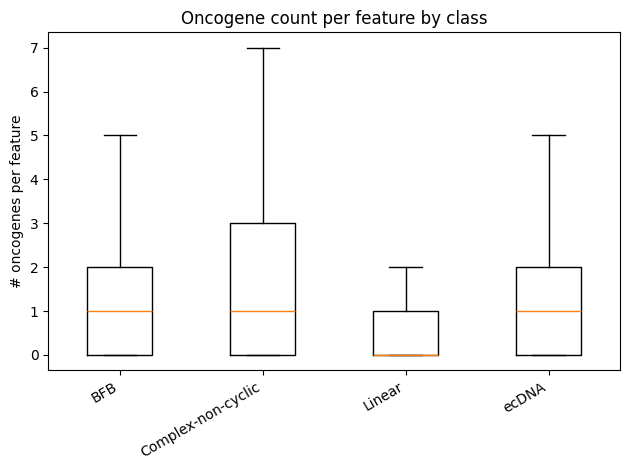

In [317]:
df_feat["oncogene_count"] = df_feat["oncogenes_list"].apply(lambda xs: len(set(xs)))

stats = (
    df_feat.groupby("Classification")["oncogene_count"]
    .describe(percentiles=[0.25,0.5,0.75,0.9])
)
print(stats)

# optional plot
classes = sorted(df_feat["Classification"].dropna().unique())
data = [df_feat.loc[df_feat["Classification"].eq(c), "oncogene_count"].values for c in classes]

plt.figure()
plt.boxplot(data, tick_labels=classes, showfliers=False)
plt.ylabel("# oncogenes per feature")
plt.title("Oncogene count per feature by class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Now lets focus on some mix datasets questions.

In [318]:
# Load all three datasets: CCLE, PCAWG, TCGA
DATA_DIR = "biomni/data/biomni_data/data_lake/"

# Load CCLE (already loaded above, but let's be explicit)
df_ccle = pd.read_csv(DATA_DIR + "CCLE.csv")
df_ccle_feat = df_ccle[df_ccle["Classification"].notna()].copy()

# Load PCAWG
df_pcawg = pd.read_csv(DATA_DIR + "PCAWG.csv")
df_pcawg_feat = df_pcawg[df_pcawg["Classification"].notna()].copy()

# Load TCGA
df_tcga = pd.read_csv(DATA_DIR + "TCGA.csv")
df_tcga_feat = df_tcga[df_tcga["Classification"].notna()].copy()

# Parse list columns for all datasets
for dataset, df_name in [("CCLE", df_ccle_feat), ("PCAWG", df_pcawg_feat), ("TCGA", df_tcga_feat)]:
    df_name["oncogenes_list"] = df_name["Oncogenes"].apply(_parse_list_cell)
    df_name["all_genes_list"] = df_name["All genes"].apply(_parse_list_cell)
    
    # Convert numeric columns
    for c in num_cols:
        if c in df_name.columns:
            df_name[c] = pd.to_numeric(df_name[c], errors="coerce")
    
    print(f"{dataset}: {df_name.shape[0]} features, {df_name['Sample name'].nunique()} unique samples")
    print(f"  Classifications: {df_name['Classification'].value_counts().to_dict()}")
    print()

# Create a combined dataset with source column
df_ccle_feat["Dataset"] = "CCLE"
df_pcawg_feat["Dataset"] = "PCAWG"
df_tcga_feat["Dataset"] = "TCGA"

df_all = pd.concat([df_ccle_feat, df_pcawg_feat, df_tcga_feat], ignore_index=True)
print(f"Combined dataset: {df_all.shape[0]} total features across {df_all['Sample name'].nunique()} unique samples")
print(f"Features by dataset: {df_all['Dataset'].value_counts().to_dict()}")


CCLE: 1157 features, 252 unique samples
  Classifications: {'Linear': 550, 'ecDNA': 297, 'Complex-non-cyclic': 196, 'BFB': 114}

PCAWG: 2703 features, 799 unique samples
  Classifications: {'Linear amplification': 1202, 'ecDNA': 714, 'Complex non-cyclic': 433, 'BFB': 354}

TCGA: 3667 features, 1008 unique samples
  Classifications: {'Linear amplification': 1859, 'ecDNA': 766, 'Complex non-cyclic': 557, 'BFB': 485}

Combined dataset: 7527 total features across 2059 unique samples
Features by dataset: {'TCGA': 3667, 'PCAWG': 2703, 'CCLE': 1157}


# 1)Is YES1 amplified as ecDNA or BFB in CCLE + PCAWG datasets? In which samples?

In [319]:
gene = "YES1"

# Filter for CCLE + PCAWG only, and only ecDNA or BFB classifications
df_combined = df_all[
    df_all["Dataset"].isin(["CCLE", "PCAWG"]) &
    df_all["Classification"].isin(["ecDNA", "BFB"])
].copy()

# Find all features containing YES1
hits = df_combined[
    df_combined["oncogenes_list"].apply(lambda xs: gene in xs)
    | df_combined["all_genes_list"].apply(lambda xs: gene in xs)
].copy()

# Summary by dataset and classification
summary = (
    hits.groupby(["Dataset", "Classification"])["Sample name"]
    .nunique()
    .reset_index(name="n_samples")
    .sort_values(["Dataset", "n_samples"], ascending=[True, False])
)

print(f"YES1 amplification summary (CCLE + PCAWG):")
print(summary.to_string(index=False))
print(f"\nTotal unique samples with YES1: {hits['Sample name'].nunique()}")

# Show sample details
print(f"\n{'='*80}")
print("Sample details with YES1 amplification:")
print(f"{'='*80}")
cols = ["Dataset", "Sample name", "Classification", "Feature ID", "Location",
        "Captured interval length", "Feature maximum copy number", "Oncogenes"]
print(hits[cols].sort_values(["Dataset", "Classification", "Sample name"]).to_string(index=False))

# List unique samples per dataset-classification combination
print(f"\n{'='*80}")
print("Unique samples by dataset and classification:")
print(f"{'='*80}")
for (dataset, classification), group in hits.groupby(["Dataset", "Classification"]):
    samples = sorted(group["Sample name"].unique())
    print(f"\n{dataset} - {classification} ({len(samples)} samples):")
    for s in samples:
        print(f"  - {s}")


YES1 amplification summary (CCLE + PCAWG):
Dataset Classification  n_samples
   CCLE            BFB          1
  PCAWG          ecDNA          1

Total unique samples with YES1: 2

Sample details with YES1 amplification:
Dataset       Sample name Classification                                                                                   Feature ID                   Location  Captured interval length  Feature maximum copy number            Oncogenes
   CCLE KYSE70_OESOPHAGUS            BFB                                                            KYSE70_OESOPHAGUS_amplicon7_BFB_1 ["'chr18:634973-4361110'"]                 3726137.0                    21.688132 ["'TYMS'", "'YES1'"]
  PCAWG   DO29980-SP63796          ecDNA 222973e2-fb4d-55ff-bab1-769a079690c5__2fb30d72-19b4-57df-96d3-c6b7c0f106a8_amplicon7_ecDNA_1    ["'18:285957-1897168'"]                 1611211.0                    43.232967 ["'TYMS'", "'YES1'"]

Unique samples by dataset and classification:

CCLE - BFB (1 sample

# 2)Is YES1 amplified as ecDNA or BFB in CCLE + PCAWG + TCGA datasets? In which samples?

In [320]:
gene = "YES1"

# Filter for CCLE + PCAWG only, and only ecDNA or BFB classifications
df_combined = df_all[
    df_all["Dataset"].isin(["CCLE", "PCAWG","TCGA"]) &
    df_all["Classification"].isin(["ecDNA", "BFB"])
].copy()

# Find all features containing YES1
hits = df_combined[
    df_combined["oncogenes_list"].apply(lambda xs: gene in xs)
    | df_combined["all_genes_list"].apply(lambda xs: gene in xs)
].copy()

# Summary by dataset and classification
summary = (
    hits.groupby(["Dataset", "Classification"])["Sample name"]
    .nunique()
    .reset_index(name="n_samples")
    .sort_values(["Dataset", "n_samples"], ascending=[True, False])
)

print(f"YES1 amplification summary (CCLE + PCAWG + TCGA):")
print(summary.to_string(index=False))
print(f"\nTotal unique samples with YES1: {hits['Sample name'].nunique()}")

# Show sample details
print(f"\n{'='*80}")
print("Sample details with YES1 amplification:")
print(f"{'='*80}")
cols = ["Dataset", "Sample name", "Classification", "Feature ID", "Location",
        "Captured interval length", "Feature maximum copy number", "Oncogenes"]
print(hits[cols].sort_values(["Dataset", "Classification", "Sample name"]).to_string(index=False))

# List unique samples per dataset-classification combination
print(f"\n{'='*80}")
print("Unique samples by dataset and classification:")
print(f"{'='*80}")
for (dataset, classification), group in hits.groupby(["Dataset", "Classification"]):
    samples = sorted(group["Sample name"].unique())
    print(f"\n{dataset} - {classification} ({len(samples)} samples):")
    for s in samples:
        print(f"  - {s}")


YES1 amplification summary (CCLE + PCAWG + TCGA):
Dataset Classification  n_samples
   CCLE            BFB          1
  PCAWG          ecDNA          1

Total unique samples with YES1: 2

Sample details with YES1 amplification:
Dataset       Sample name Classification                                                                                   Feature ID                   Location  Captured interval length  Feature maximum copy number            Oncogenes
   CCLE KYSE70_OESOPHAGUS            BFB                                                            KYSE70_OESOPHAGUS_amplicon7_BFB_1 ["'chr18:634973-4361110'"]                 3726137.0                    21.688132 ["'TYMS'", "'YES1'"]
  PCAWG   DO29980-SP63796          ecDNA 222973e2-fb4d-55ff-bab1-769a079690c5__2fb30d72-19b4-57df-96d3-c6b7c0f106a8_amplicon7_ecDNA_1    ["'18:285957-1897168'"]                 1611211.0                    43.232967 ["'TYMS'", "'YES1'"]

Unique samples by dataset and classification:

CCLE - BFB (1

# 3)Summarize the size distribution of all BFB amplifications (in all datasets)

Total BFB features across all datasets: 953
BFB features with size data: 942

BFB features by dataset:
{'TCGA': 485, 'PCAWG': 354, 'CCLE': 114}

Size distribution statistics (Captured interval length):
count    9.420000e+02
mean     1.946014e+06
std      2.937918e+06
min      7.055000e+03
10%      1.548031e+05
25%      4.084895e+05
50%      1.026258e+06
75%      2.355640e+06
90%      4.543075e+06
max      3.851021e+07
Name: Captured interval length, dtype: float64

Size distribution by dataset:

CCLE (n=114):
  Mean: 2271736.63, Median: 1276367.00
  Min: 59463.00, Max: 21246834.00

PCAWG (n=352):
  Mean: 1623699.69, Median: 832052.50
  Min: 18289.00, Max: 21027074.00

TCGA (n=476):
  Mean: 2106355.80, Median: 1100172.00
  Min: 7055.00, Max: 38510213.00


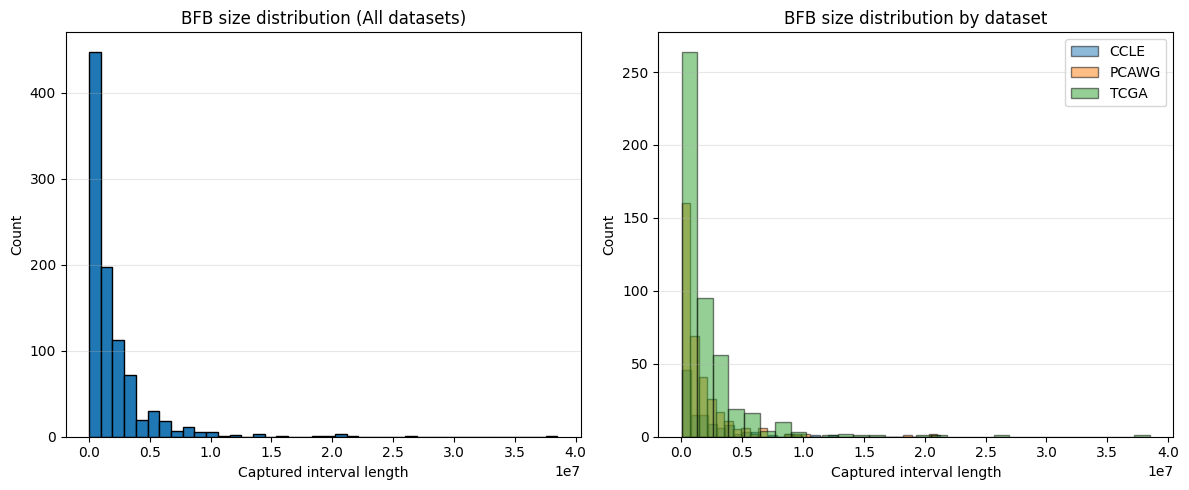

In [321]:
# Filter for BFB across all datasets
bfb_all = df_all[df_all["Classification"] == "BFB"].copy()
sizes_all = bfb_all["Captured interval length"].dropna()

print(f"Total BFB features across all datasets: {len(bfb_all)}")
print(f"BFB features with size data: {sizes_all.notna().sum()}")
print(f"\nBFB features by dataset:")
print(bfb_all["Dataset"].value_counts().to_dict())

print(f"\n{'='*80}")
print("Size distribution statistics (Captured interval length):")
print(f"{'='*80}")
print(sizes_all.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

# Compare by dataset
print(f"\n{'='*80}")
print("Size distribution by dataset:")
print(f"{'='*80}")
for dataset in ["CCLE", "PCAWG", "TCGA"]:
    dataset_sizes = bfb_all[bfb_all["Dataset"] == dataset]["Captured interval length"].dropna()
    if len(dataset_sizes) > 0:
        print(f"\n{dataset} (n={len(dataset_sizes)}):")
        print(f"  Mean: {dataset_sizes.mean():.2f}, Median: {dataset_sizes.median():.2f}")
        print(f"  Min: {dataset_sizes.min():.2f}, Max: {dataset_sizes.max():.2f}")

# Histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(sizes_all, bins=40, edgecolor='black')
plt.xlabel("Captured interval length")
plt.ylabel("Count")
plt.title("BFB size distribution (All datasets)")
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
for dataset in ["CCLE", "PCAWG", "TCGA"]:
    dataset_sizes = bfb_all[bfb_all["Dataset"] == dataset]["Captured interval length"].dropna()
    if len(dataset_sizes) > 0:
        plt.hist(dataset_sizes, bins=30, alpha=0.5, label=dataset, edgecolor='black')
plt.xlabel("Captured interval length")
plt.ylabel("Count")
plt.title("BFB size distribution by dataset")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# 4) List all BFB amplifications in HARA across all datasets (feature IDs, loci, genes, copy number)

In [322]:
# Search for HARA samples across all datasets
sample_name = "HARA"

# Filter for BFB features with HARA in sample name
hara_bfb = df_all[
    df_all["Sample name"].str.contains(sample_name, case=False, na=False) &
    (df_all["Classification"] == "BFB")
].copy()

print(f"BFB features in samples containing '{sample_name}': {len(hara_bfb)}")
print(f"\nDataset distribution:")
print(hara_bfb["Dataset"].value_counts().to_dict())

# Display columns
cols = [
    "Dataset", "Sample name", "Classification", "AA amplicon number", "Feature ID", 
    "Location", "Captured interval length", "Feature median copy number", 
    "Feature maximum copy number", "Oncogenes", "All genes"
]

print(f"\n{'='*120}")
print("All BFB amplifications in HARA samples:")
print(f"{'='*120}")

if len(hara_bfb) > 0:
    # Sort by Dataset, Sample name, then AA amplicon number
    sorted_hara = hara_bfb[cols].sort_values(["Dataset", "Sample name", "AA amplicon number", "Feature ID"])
    print(sorted_hara.to_string(index=False))
    
    # Summary by sample
    print(f"\n{'='*120}")
    print("Summary by sample:")
    print(f"{'='*120}")
    for (dataset, sample), group in hara_bfb.groupby(["Dataset", "Sample name"]):
        print(f"\n{dataset} - {sample}: {len(group)} BFB features")
        print(f"  Total oncogenes: {set(g for genes in group['oncogenes_list'] for g in genes)}")
else:
    print("No BFB features found in samples containing 'HARA'")


BFB features in samples containing 'HARA': 1

Dataset distribution:
{'CCLE': 1}

All BFB amplifications in HARA samples:
Dataset Sample name Classification  AA amplicon number                Feature ID                                                   Location  Captured interval length  Feature median copy number  Feature maximum copy number   Oncogenes                                                                                                                                                                              All genes
   CCLE   HARA_LUNG            BFB                 6.0 HARA_LUNG_amplicon6_BFB_1 ["'chr11:34893970-37730986'", "'chr11:37761005-41072281'"]                 6148292.0                   15.180671                    56.560276 ["'TRAF6'"] ["'APIP'", "'C11orf74'", "'CD44'", "'COMMD9'", "'FJX1'", "'LDLRAD3'", "'LRRC4C'", "'PAMR1'", "'PDHX'", "'PRR5L'", "'RAG1'", "'RAG2'", "'SLC1A2'", "'SNORD164'", "'TRAF6'", "'TRIM44'"]

Summary by sample:

CCLE - HARA_LUNG: 1 BF

# 5) Which genes are most frequently amplified as BFB in TCGA + PCAWG? (top 25)

In [323]:
from collections import Counter

# Filter for BFB in TCGA + PCAWG only
bfb_tcga_pcawg = df_all[
    df_all["Dataset"].isin(["TCGA", "PCAWG"]) &
    (df_all["Classification"] == "BFB")
].copy()

print(f"Total BFB features in TCGA + PCAWG: {len(bfb_tcga_pcawg)}")
print(f"  TCGA: {(bfb_tcga_pcawg['Dataset'] == 'TCGA').sum()}")
print(f"  PCAWG: {(bfb_tcga_pcawg['Dataset'] == 'PCAWG').sum()}")

# Count oncogenes across BFB features
ctr = Counter()
for genes in bfb_tcga_pcawg["oncogenes_list"]:
    ctr.update(set(genes))  # set() to avoid double-counting within one feature

top = pd.DataFrame(ctr.most_common(25), columns=["Gene", "BFB_feature_count"])

print(f"\n{'='*60}")
print("Top 25 genes most frequently amplified as BFB (TCGA + PCAWG):")
print(f"{'='*60}")
print(top.to_string(index=False))

Total BFB features in TCGA + PCAWG: 839
  TCGA: 485
  PCAWG: 354

Top 25 genes most frequently amplified as BFB (TCGA + PCAWG):
    Gene  BFB_feature_count
    CTTN                 36
   CCNE1                 20
 C19orf2                 19
C17orf37                 19
   ERBB2                 19
    KRAS                 18
   CCND1                 18
    FGF4                 17
    EGFR                 17
    LSM1                 15
   DDHD2                 15
    YAP1                 14
 WHSC1L1                 14
   FGFR1                 14
    FGF3                 14
  ZNF703                 13
   CDK12                 12
    MDM2                 12
   MMP12                 12
   BIRC3                 12
   BIRC2                 12
  YEATS4                 12
    CSF3                 11
    BRF2                 11
    AKT2                 10


# 6) Show the distribution of amplification classes across cancer types (Tissue of origin) for all datasets

Amplification class distribution by tissue (all datasets):
Classification                      BFB  Complex-non-cyclic  Linear  ecDNA
Tissue of origin                                                          
autonomic ganglia                     0                   0       0      1
bone                                  1                   0       1      0
breast                               13                  32     101     62
central nervous system                0                   5       7      6
endometrium                           2                   5      14     12
haematopoietic and lymphoid tissue    0                   5      18      5
kidney                                2                   0       3      2
large intestine                       3                   7      12      4
liver                                 4                   8       8      5
lung                                 43                  67     193    104
oesophagus                           11  

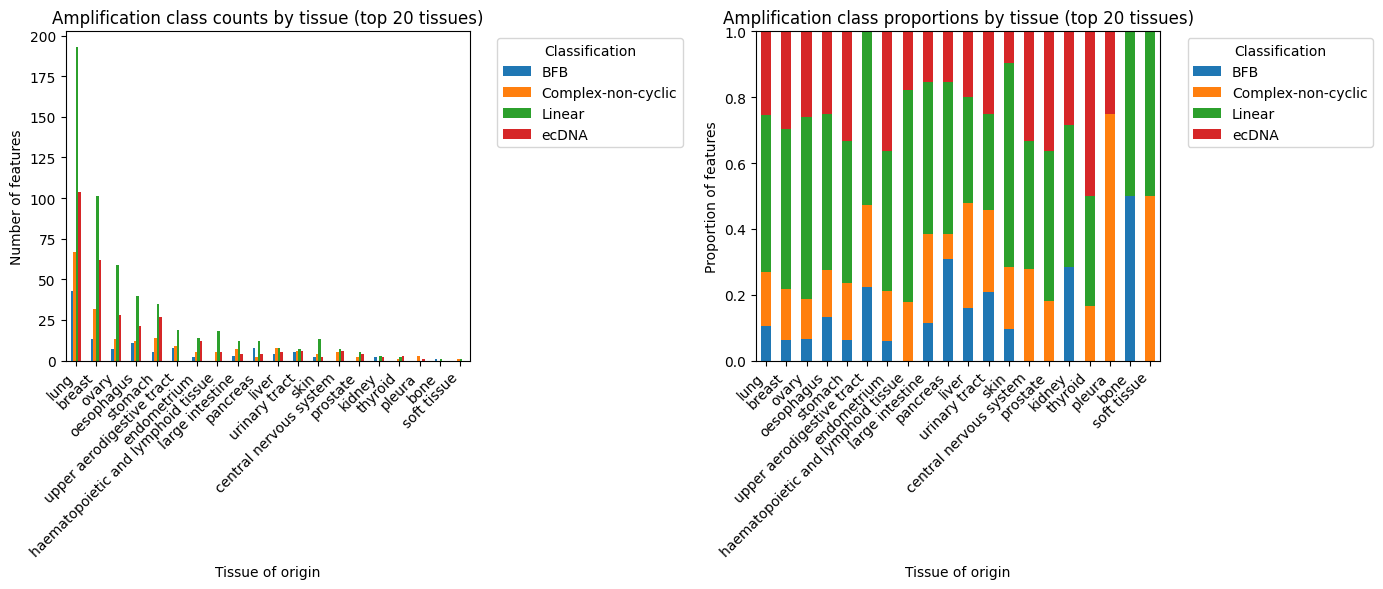


Feature counts by tissue and dataset:
Dataset                             CCLE
Tissue of origin                        
autonomic ganglia                      1
bone                                   2
breast                               208
central nervous system                18
endometrium                           33
haematopoietic and lymphoid tissue    28
kidney                                 7
large intestine                       26
liver                                 25
lung                                 407
oesophagus                            84
ovary                                107
pancreas                              26
pleura                                 4
prostate                              11
skin                                  21
soft tissue                            2
stomach                               81
thyroid                                6
upper aerodigestive tract             36
urinary tract                         24


In [324]:
# Cross-tabulation of Tissue of origin vs Classification across all datasets
tab_all = pd.crosstab(df_all["Tissue of origin"], df_all["Classification"]).sort_index()

print(f"{'='*80}")
print("Amplification class distribution by tissue (all datasets):")
print(f"{'='*80}")
print(tab_all.head(30))

# Calculate proportions per tissue
prop_all = tab_all.div(tab_all.sum(axis=1), axis=0).fillna(0)

print(f"\n{'='*80}")
print("Proportions by tissue (first 30 tissues):")
print(f"{'='*80}")
print(prop_all.head(30))

# Overall summary by classification
print(f"\n{'='*80}")
print("Overall feature counts by classification:")
print(f"{'='*80}")
print(tab_all.sum(axis=0))

# Plot top tissues by total feature count
top_tissues_all = tab_all.sum(axis=1).sort_values(ascending=False).head(20).index

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
tab_all.loc[top_tissues_all].plot(kind="bar", stacked=False, ax=plt.gca())
plt.ylabel("Number of features")
plt.xlabel("Tissue of origin")
plt.title("Amplification class counts by tissue (top 20 tissues)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Classification", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.subplot(1, 2, 2)
prop_all.loc[top_tissues_all].plot(kind="bar", stacked=True, ax=plt.gca())
plt.ylabel("Proportion of features")
plt.xlabel("Tissue of origin")
plt.title("Amplification class proportions by tissue (top 20 tissues)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Classification", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# Also show breakdown by dataset
print(f"\n{'='*80}")
print("Feature counts by tissue and dataset:")
print(f"{'='*80}")
tissue_dataset = pd.crosstab(df_all["Tissue of origin"], df_all["Dataset"]).sort_index()
print(tissue_dataset.head(30))

# 7) Do Complexity scores differ between ecDNA vs BFB vs Linear vs Complex-non-cyclic? (all datasets)

Complexity score statistics by classification (all datasets):
                     count      mean       std       min       25%       50%  \
Classification                                                                 
BFB                  953.0  1.069803  0.585119  0.130456  0.714392  0.957670   
Complex-non-cyclic  1186.0  1.115112  0.551069  0.040563  0.673477  1.043254   
Linear              3611.0  0.411354  0.349447  0.000000  0.159684  0.359739   
ecDNA               1777.0  0.586860  0.463794  0.043772  0.279073  0.367357   

                         75%       max  
Classification                          
BFB                 1.223679  4.224270  
Complex-non-cyclic  1.492578  3.016525  
Linear              0.606962  2.579602  
ecDNA               0.707977  2.851305  

Complexity score by classification and dataset:

CCLE:
                    count      mean       50%       min       max
Classification                                                   
BFB                 114

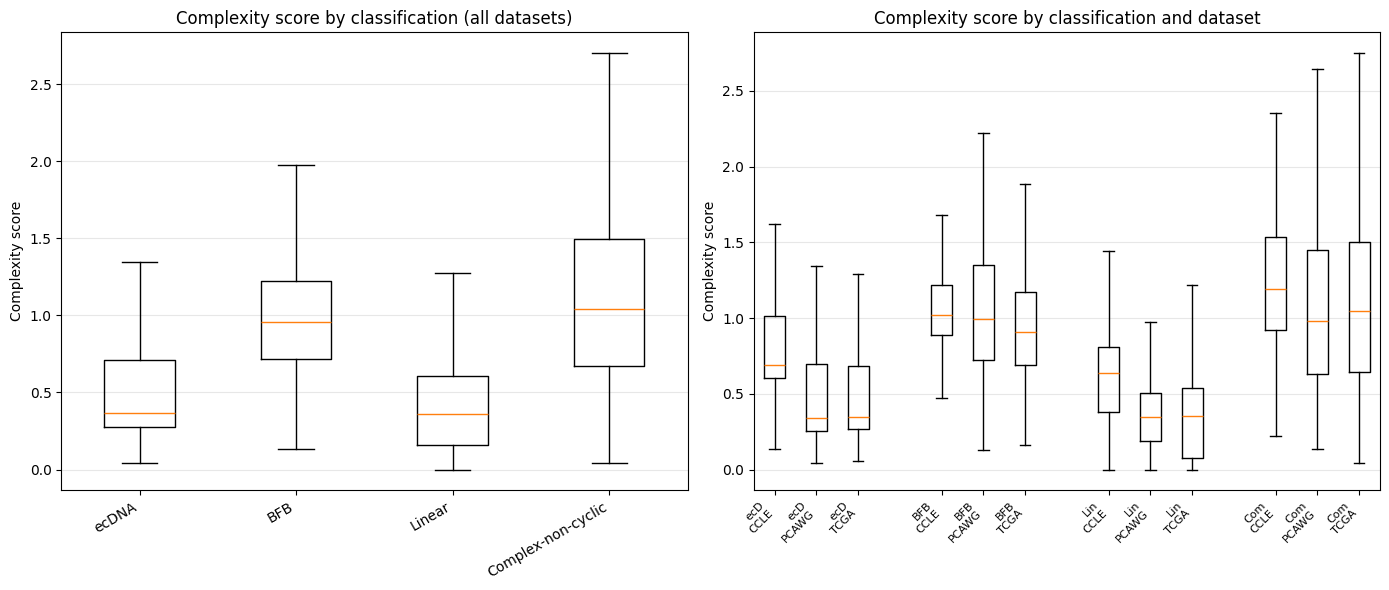

In [328]:
# Standardize classification names first (fix inconsistencies across datasets)
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",  # PCAWG/TCGA use space, CCLE uses hyphen
    "Linear amplification": "Linear"  # PCAWG/TCGA use "Linear amplification", CCLE uses "Linear"
})

# Filter for rows with Complexity score data
x_all = df_all_fixed[["Classification", "Complexity score", "Dataset"]].dropna().copy()

print(f"{'='*80}")
print("Complexity score statistics by classification (all datasets):")
print(f"{'='*80}")
stats_all = x_all.groupby("Classification")["Complexity score"].describe(percentiles=[0.25, 0.5, 0.75])
print(stats_all)

# Breakdown by dataset
print(f"\n{'='*80}")
print("Complexity score by classification and dataset:")
print(f"{'='*80}")
for dataset in ["CCLE", "PCAWG", "TCGA"]:
    dataset_data = x_all[x_all["Dataset"] == dataset]
    if len(dataset_data) > 0:
        print(f"\n{dataset}:")
        stats_dataset = dataset_data.groupby("Classification")["Complexity score"].describe(percentiles=[0.5])
        print(stats_dataset[["count", "mean", "50%", "min", "max"]])

# Boxplot
classes = ["ecDNA", "BFB", "Linear", "Complex-non-cyclic"]
data_all = [x_all.loc[x_all["Classification"].eq(c), "Complexity score"].values 
            for c in classes if c in x_all["Classification"].unique()]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.boxplot(data_all, 
            tick_labels=[c for c in classes if c in x_all["Classification"].unique()], 
            showfliers=False)
plt.ylabel("Complexity score")
plt.title("Complexity score by classification (all datasets)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis='y', alpha=0.3)

# Boxplot by dataset
plt.subplot(1, 2, 2)
datasets = ["CCLE", "PCAWG", "TCGA"]
positions = []
labels = []
all_data = []
pos = 1

for cls in classes:
    if cls in x_all["Classification"].unique():
        for dataset in datasets:
            dataset_cls_data = x_all[
                (x_all["Classification"] == cls) & 
                (x_all["Dataset"] == dataset)
            ]["Complexity score"].values
            if len(dataset_cls_data) > 0:
                all_data.append(dataset_cls_data)
                positions.append(pos)
                labels.append(f"{cls[:3]}\n{dataset}")
                pos += 1
        pos += 1  # gap between classifications

if all_data:
    plt.boxplot(all_data, positions=positions, showfliers=False)
    plt.xticks(positions, labels, rotation=45, ha="right", fontsize=8)
    plt.ylabel("Complexity score")
    plt.title("Complexity score by classification and dataset")
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 8) For ecDNA vs BFB, how does size relate to max copy number? (scatter + correlation) (all datasets)

Size vs max copy number correlation (all datasets):
ecDNA: n=1777 corr(size, maxCN)=0.1195
BFB: n=942 corr(size, maxCN)=0.0325

Correlations by dataset:

CCLE:
  ecDNA: n=297 corr=0.0498
  BFB: n=114 corr=-0.0029

PCAWG:
  ecDNA: n=714 corr=0.1597
  BFB: n=352 corr=0.1230

TCGA:
  ecDNA: n=766 corr=0.1216
  BFB: n=476 corr=0.0107


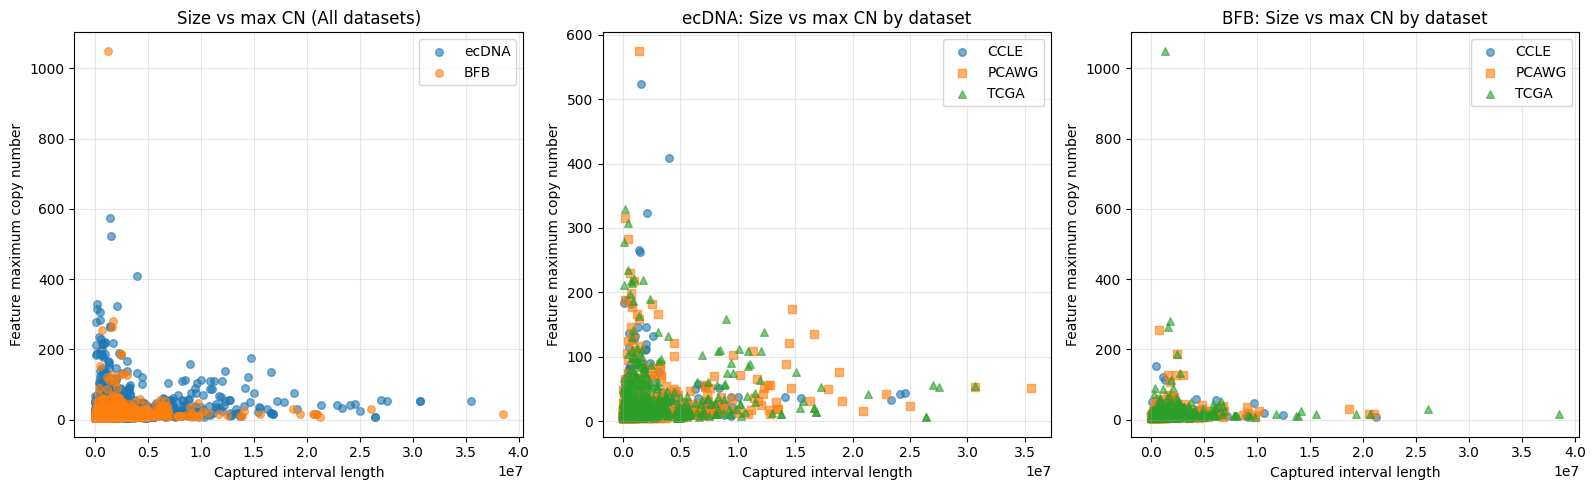

In [329]:
# Standardize classification names first
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Filter for ecDNA and BFB only
sub_all = df_all_fixed[df_all_fixed["Classification"].isin(["ecDNA", "BFB"])].copy()
sub_all = sub_all.dropna(subset=["Captured interval length", "Feature maximum copy number"])

print(f"{'='*80}")
print("Size vs max copy number correlation (all datasets):")
print(f"{'='*80}")

# Overall correlations per class
for cls in ["ecDNA", "BFB"]:
    s = sub_all[sub_all["Classification"] == cls]
    corr = s["Captured interval length"].corr(s["Feature maximum copy number"])
    print(f"{cls}: n={len(s)} corr(size, maxCN)={corr:.4f}")

# Correlations by dataset
print(f"\n{'='*80}")
print("Correlations by dataset:")
print(f"{'='*80}")
for dataset in ["CCLE", "PCAWG", "TCGA"]:
    print(f"\n{dataset}:")
    for cls in ["ecDNA", "BFB"]:
        s = sub_all[(sub_all["Classification"] == cls) & (sub_all["Dataset"] == dataset)]
        if len(s) > 0:
            corr = s["Captured interval length"].corr(s["Feature maximum copy number"])
            print(f"  {cls}: n={len(s)} corr={corr:.4f}")

# Scatter plots
plt.figure(figsize=(16, 5))

# Overall scatter
plt.subplot(1, 3, 1)
for cls in ["ecDNA", "BFB"]:
    s = sub_all[sub_all["Classification"] == cls]
    plt.scatter(s["Captured interval length"], s["Feature maximum copy number"], 
                label=cls, alpha=0.6, s=30)
plt.xlabel("Captured interval length")
plt.ylabel("Feature maximum copy number")
plt.title("Size vs max CN (All datasets)")
plt.legend()
plt.grid(alpha=0.3)

# Scatter by dataset - ecDNA
plt.subplot(1, 3, 2)
for dataset, marker in zip(["CCLE", "PCAWG", "TCGA"], ['o', 's', '^']):
    s = sub_all[(sub_all["Classification"] == "ecDNA") & (sub_all["Dataset"] == dataset)]
    plt.scatter(s["Captured interval length"], s["Feature maximum copy number"], 
                label=dataset, alpha=0.6, s=30, marker=marker)
plt.xlabel("Captured interval length")
plt.ylabel("Feature maximum copy number")
plt.title("ecDNA: Size vs max CN by dataset")
plt.legend()
plt.grid(alpha=0.3)

# Scatter by dataset - BFB
plt.subplot(1, 3, 3)
for dataset, marker in zip(["CCLE", "PCAWG", "TCGA"], ['o', 's', '^']):
    s = sub_all[(sub_all["Classification"] == "BFB") & (sub_all["Dataset"] == dataset)]
    plt.scatter(s["Captured interval length"], s["Feature maximum copy number"], 
                label=dataset, alpha=0.6, s=30, marker=marker)
plt.xlabel("Captured interval length")
plt.ylabel("Feature maximum copy number")
plt.title("BFB: Size vs max CN by dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9) What are the highest copy-number amplifications in CCLE + PCAWG? (top 5)

In [330]:
# Filter for CCLE + PCAWG only
df_ccle_pcawg = df_all[df_all["Dataset"].isin(["CCLE", "PCAWG"])].copy()

# Find top 5 by maximum copy number
top5 = (
    df_ccle_pcawg.dropna(subset=["Feature maximum copy number"])
    .sort_values("Feature maximum copy number", ascending=False)
    .head(5)
)

cols = ["Dataset", "Sample name", "Tissue of origin", "Classification", "Feature ID", "Location",
        "Feature maximum copy number", "Feature median copy number", "Captured interval length", "Oncogenes"]

print(f"{'='*120}")
print("Top 5 highest copy-number amplifications (CCLE + PCAWG):")
print(f"{'='*120}")
print(top5[cols].to_string(index=False))

# Summary statistics
print(f"\n{'='*120}")
print("Summary:")
print(f"{'='*120}")
print(f"Highest CN: {top5['Feature maximum copy number'].max():.2f}")
print(f"Mean of top 5: {top5['Feature maximum copy number'].mean():.2f}")
print(f"\nClassification breakdown:")
print(top5["Classification"].value_counts())
print(f"\nDataset breakdown:")
print(top5["Dataset"].value_counts())

Top 5 highest copy-number amplifications (CCLE + PCAWG):
Dataset     Sample name Tissue of origin Classification                                                                                    Feature ID                                                                                                                                                                                                                                                                                                                                                              Location  Feature maximum copy number  Feature median copy number  Captured interval length                                                     Oncogenes
  PCAWG DO35573-SP78718              NaN          ecDNA  bc53f9a0-1543-54a2-8c2f-29f3093b72db__419b278b-557a-54d0-9923-3e7eee7bd14b_amplicon1_ecDNA_1                                                                                                                                             

# 10) Which oncogenes appear in both ecDNA and BFB across all datasets?

In [331]:
from collections import defaultdict

# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Track which classifications each gene appears in
gene_classes = defaultdict(set)

for _, r in df_all_fixed.iterrows():
    for g in r["oncogenes_list"]:
        gene_classes[g].add(r["Classification"])

# Find genes appearing in both ecDNA and BFB
both = sorted([g for g, cls in gene_classes.items() if {"ecDNA", "BFB"} <= cls])

print(f"{'='*80}")
print("Oncogenes appearing in both ecDNA and BFB (across all datasets):")
print(f"{'='*80}")
print(f"Total count: {len(both)}\n")

# Display in columns for better readability
if both:
    # Print in multiple columns
    cols = 4
    for i in range(0, len(both), cols):
        row_genes = both[i:i+cols]
        print("  ".join(f"{g:20}" for g in row_genes))
    
    # Additional analysis: breakdown by dataset
    print(f"\n{'='*80}")
    print("Breakdown by dataset:")
    print(f"{'='*80}")
    
    for dataset in ["CCLE", "PCAWG", "TCGA"]:
        df_dataset = df_all_fixed[df_all_fixed["Dataset"] == dataset]
        
        gene_classes_ds = defaultdict(set)
        for _, r in df_dataset.iterrows():
            for g in r["oncogenes_list"]:
                gene_classes_ds[g].add(r["Classification"])
        
        both_ds = sorted([g for g, cls in gene_classes_ds.items() if {"ecDNA", "BFB"} <= cls])
        print(f"\n{dataset}: {len(both_ds)} genes in both ecDNA and BFB")
        
    # Show top genes by total feature count
    print(f"\n{'='*80}")
    print("Top 20 genes by total feature count (ecDNA + BFB combined):")
    print(f"{'='*80}")
    
    from collections import Counter
    gene_counts = Counter()
    
    for _, r in df_all_fixed[df_all_fixed["Classification"].isin(["ecDNA", "BFB"])].iterrows():
        for g in set(r["oncogenes_list"]):
            if g in both:
                gene_counts[g] += 1
    
    top_genes = pd.DataFrame(gene_counts.most_common(20), columns=["Gene", "Total_features"])
    print(top_genes.to_string(index=False))
else:
    print("No genes found in both ecDNA and BFB")

Oncogenes appearing in both ecDNA and BFB (across all datasets):
Total count: 279

ABL2                  ACTN4                 ADAM9                 AGAP2               
AHI1                  AIMP2                 AKAP9                 AKT2                
AQP1                  ARHGEF2               ARID2                 ARNT                
ASXL1                 BAIAP2L1              BCAR4                 BCL11A              
BCL2L1                BCL3                  BIRC2                 BIRC3               
BIRC5                 BLK                   BRD4                  BRF2                
C11orf30              C16orf75              C17orf37              C19orf2             
C21orf34              C6orf108              CALR                  CAV1                
CBLC                  CBX8                  CCDC28A               CCND1               
CCND2                 CCND3                 CCNE1                 CD274               
CDC5L                 CDC6                  CDK

# 11) Which samples contain both ecDNA and BFB amplifications? (all datasets)

In [332]:
# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Group by sample and find which classifications each sample has
sample_classes = (
    df_all_fixed.groupby("Sample name")["Classification"]
    .apply(set)
)

# Find samples with both ecDNA and BFB
both = sample_classes[sample_classes.apply(lambda x: {"ecDNA", "BFB"} <= x)]

print(f"{'='*80}")
print("Samples with both ecDNA and BFB amplifications (all datasets):")
print(f"{'='*80}")
print(f"Total count: {len(both)} samples\n")

# Get dataset information for these samples
samples_with_both = both.index.tolist()
dataset_info = df_all_fixed[df_all_fixed["Sample name"].isin(samples_with_both)][["Sample name", "Dataset", "Tissue of origin"]].drop_duplicates()

# Breakdown by dataset
print(f"{'='*80}")
print("Breakdown by dataset:")
print(f"{'='*80}")
dataset_counts = dataset_info.groupby("Dataset")["Sample name"].nunique()
for dataset in ["CCLE", "PCAWG", "TCGA"]:
    if dataset in dataset_counts.index:
        print(f"{dataset}: {dataset_counts[dataset]} samples")

# Show samples grouped by dataset
print(f"\n{'='*80}")
print("Sample list by dataset:")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG", "TCGA"]:
    dataset_samples = dataset_info[dataset_info["Dataset"] == dataset].sort_values("Sample name")
    if len(dataset_samples) > 0:
        print(f"\n{dataset} ({len(dataset_samples)} samples):")
        for _, row in dataset_samples.iterrows():
            print(f"  {row['Sample name']:50} - {row['Tissue of origin']}")

# Additional statistics: count features per sample
print(f"\n{'='*80}")
print("Top 20 samples by total feature count (ecDNA + BFB):")
print(f"{'='*80}")

feature_counts = (
    df_all_fixed[
        df_all_fixed["Sample name"].isin(samples_with_both) &
        df_all_fixed["Classification"].isin(["ecDNA", "BFB"])
    ]
    .groupby(["Sample name", "Classification"])
    .size()
    .unstack(fill_value=0)
)

feature_counts["Total"] = feature_counts.sum(axis=1)
feature_counts = feature_counts.sort_values("Total", ascending=False)

# Merge with dataset info
feature_counts_with_dataset = feature_counts.merge(
    dataset_info[["Sample name", "Dataset"]].drop_duplicates().set_index("Sample name"),
    left_index=True,
    right_index=True
)

print(feature_counts_with_dataset.head(20).to_string())

Samples with both ecDNA and BFB amplifications (all datasets):
Total count: 275 samples

Breakdown by dataset:
CCLE: 51 samples
PCAWG: 101 samples
TCGA: 123 samples

Sample list by dataset:

CCLE (51 samples):
  ABC1_LUNG                                          - lung
  AU565_BREAST                                       - breast
  BT20_BREAST                                        - breast
  CHAGOK1_LUNG                                       - lung
  CORL88_LUNG                                        - lung
  COV644_OVARY                                       - ovary
  DANG_PANCREAS                                      - pancreas
  DMS114_LUNG                                        - lung
  DMS273_LUNG                                        - lung
  EBC1_LUNG                                          - lung
  EFM19_BREAST                                       - breast
  HARA_LUNG                                          - lung
  HCC1500_BREAST                                     - brea

# 12) Are ecDNA amplifications larger than BFB on average? (CCLE vs PCAWG comparison)

Size distribution (Captured interval length) - ecDNA vs BFB:
                        count          mean           std      min        25%  \
Dataset Classification                                                          
CCLE    BFB             114.0  2.271737e+06  2.991727e+06  59463.0  503736.75   
        ecDNA           297.0  2.096639e+06  3.299880e+06  10387.0  260748.00   
PCAWG   BFB             352.0  1.623700e+06  2.471572e+06  18289.0  319903.50   
        ecDNA           714.0  2.163344e+06  3.663465e+06  10763.0  240621.50   

                              50%         75%         max  
Dataset Classification                                     
CCLE    BFB             1276367.0  2929108.75  21246834.0  
        ecDNA            985738.0  2233311.00  24593843.0  
PCAWG   BFB              832052.5  2005515.75  21027074.0  
        ecDNA            831895.5  2392376.00  35518051.0  

Overall comparison (CCLE + PCAWG combined):
                 count          mean           

/var/folders/tx/2r28t0fx5kx_0y56pcvjsvwc0000gn/T/ipykernel_64864/412228507.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_overall, labels=["ecDNA", "BFB"], showfliers=False)
/var/folders/tx/2r28t0fx5kx_0y56pcvjsvwc0000gn/T/ipykernel_64864/412228507.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_ccle, labels=["ecDNA", "BFB"], showfliers=False)
/var/folders/tx/2r28t0fx5kx_0y56pcvjsvwc0000gn/T/ipykernel_64864/412228507.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(data_pcawg, labels=["ecDNA", "BFB"], showfliers=False)


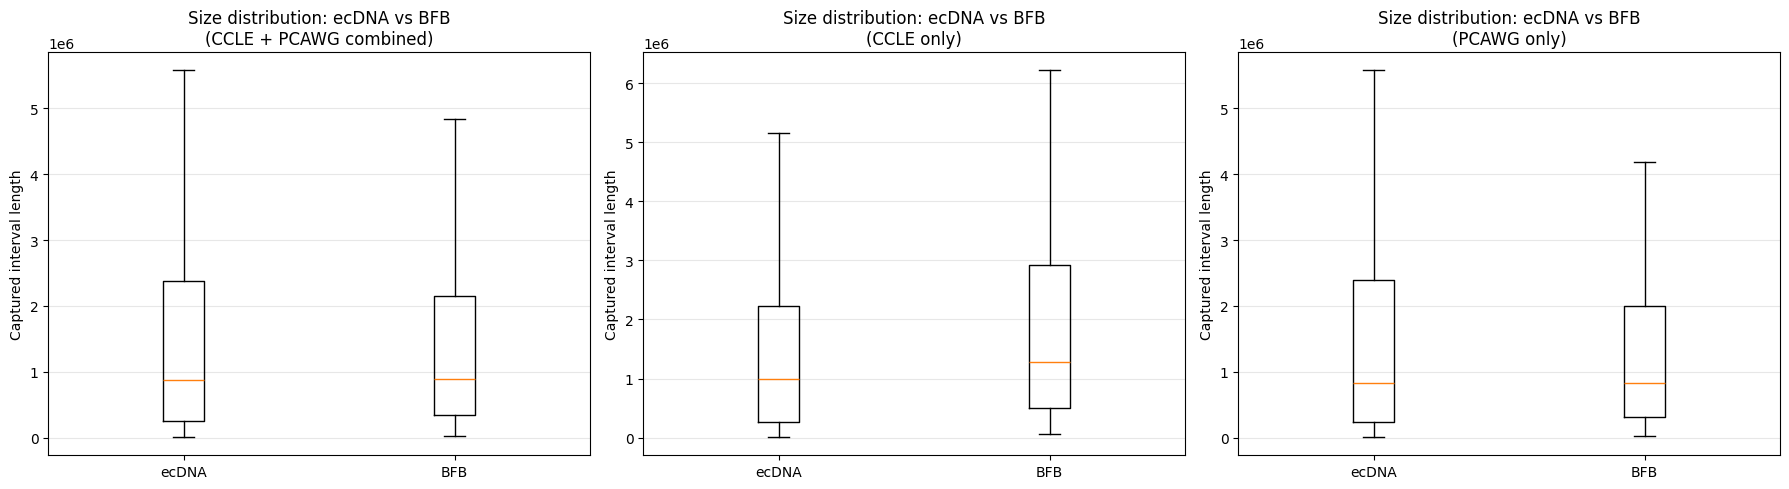

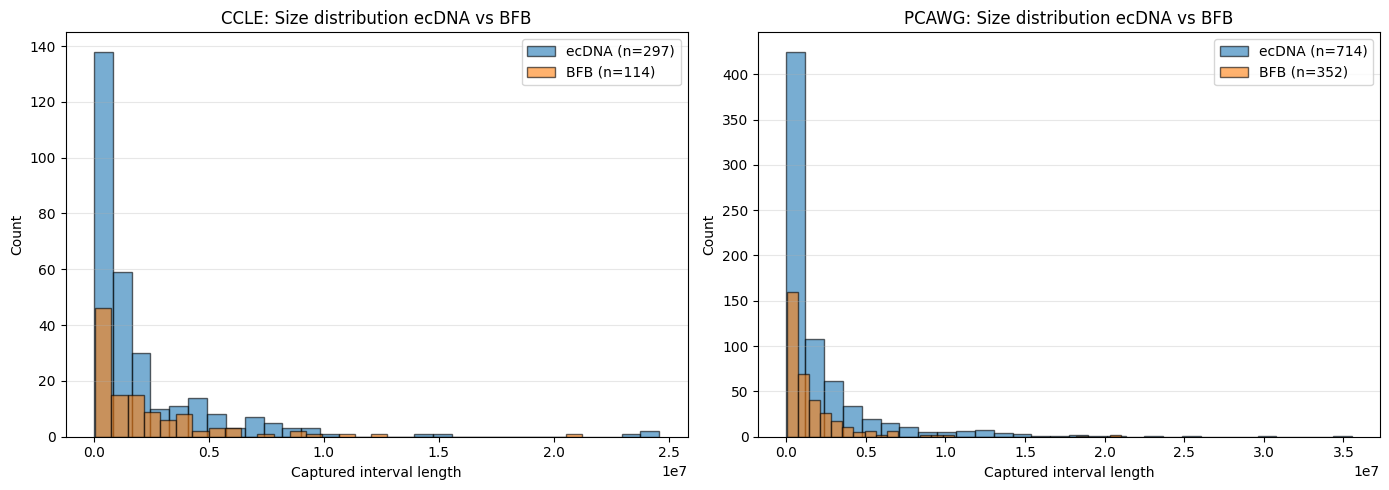

In [333]:
# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Filter for CCLE and PCAWG only, and only ecDNA and BFB
df_subset = df_all_fixed[
    df_all_fixed["Dataset"].isin(["CCLE", "PCAWG"]) &
    df_all_fixed["Classification"].isin(["ecDNA", "BFB"])
].copy()

# Get size statistics
sizes = (
    df_subset[["Classification", "Dataset", "Captured interval length"]]
    .dropna()
    .groupby(["Dataset", "Classification"])["Captured interval length"]
    .describe()
)

print(f"{'='*80}")
print("Size distribution (Captured interval length) - ecDNA vs BFB:")
print(f"{'='*80}")
print(sizes)

# Overall comparison (across both datasets)
print(f"\n{'='*80}")
print("Overall comparison (CCLE + PCAWG combined):")
print(f"{'='*80}")
overall = (
    df_subset.dropna(subset=["Captured interval length"])
    .groupby("Classification")["Captured interval length"]
    .describe()
)
print(overall)

# Statistical comparison
print(f"\n{'='*80}")
print("Mean size ratios:")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG"]:
    dataset_data = df_subset[df_subset["Dataset"] == dataset].dropna(subset=["Captured interval length"])
    ecdna_mean = dataset_data[dataset_data["Classification"] == "ecDNA"]["Captured interval length"].mean()
    bfb_mean = dataset_data[dataset_data["Classification"] == "BFB"]["Captured interval length"].mean()
    
    if not pd.isna(ecdna_mean) and not pd.isna(bfb_mean) and bfb_mean > 0:
        ratio = ecdna_mean / bfb_mean
        print(f"{dataset}: ecDNA mean / BFB mean = {ecdna_mean:.2f} / {bfb_mean:.2f} = {ratio:.2f}x")
        if ratio > 1:
            print(f"  → ecDNA is {ratio:.2f}x larger than BFB on average")
        else:
            print(f"  → BFB is {1/ratio:.2f}x larger than ecDNA on average")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot 1: Comparison by classification (overall)
ax1 = axes[0]
data_overall = [
    df_subset[df_subset["Classification"] == "ecDNA"]["Captured interval length"].dropna(),
    df_subset[df_subset["Classification"] == "BFB"]["Captured interval length"].dropna()
]
ax1.boxplot(data_overall, labels=["ecDNA", "BFB"], showfliers=False)
ax1.set_ylabel("Captured interval length")
ax1.set_title("Size distribution: ecDNA vs BFB\n(CCLE + PCAWG combined)")
ax1.grid(axis='y', alpha=0.3)

# Boxplot 2: CCLE comparison
ax2 = axes[1]
ccle_data = df_subset[df_subset["Dataset"] == "CCLE"]
data_ccle = [
    ccle_data[ccle_data["Classification"] == "ecDNA"]["Captured interval length"].dropna(),
    ccle_data[ccle_data["Classification"] == "BFB"]["Captured interval length"].dropna()
]
ax2.boxplot(data_ccle, labels=["ecDNA", "BFB"], showfliers=False)
ax2.set_ylabel("Captured interval length")
ax2.set_title("Size distribution: ecDNA vs BFB\n(CCLE only)")
ax2.grid(axis='y', alpha=0.3)

# Boxplot 3: PCAWG comparison
ax3 = axes[2]
pcawg_data = df_subset[df_subset["Dataset"] == "PCAWG"]
data_pcawg = [
    pcawg_data[pcawg_data["Classification"] == "ecDNA"]["Captured interval length"].dropna(),
    pcawg_data[pcawg_data["Classification"] == "BFB"]["Captured interval length"].dropna()
]
ax3.boxplot(data_pcawg, labels=["ecDNA", "BFB"], showfliers=False)
ax3.set_ylabel("Captured interval length")
ax3.set_title("Size distribution: ecDNA vs BFB\n(PCAWG only)")
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CCLE histogram
ax1 = axes[0]
ccle_ecdna = ccle_data[ccle_data["Classification"] == "ecDNA"]["Captured interval length"].dropna()
ccle_bfb = ccle_data[ccle_data["Classification"] == "BFB"]["Captured interval length"].dropna()
ax1.hist(ccle_ecdna, bins=30, alpha=0.6, label=f"ecDNA (n={len(ccle_ecdna)})", edgecolor='black')
ax1.hist(ccle_bfb, bins=30, alpha=0.6, label=f"BFB (n={len(ccle_bfb)})", edgecolor='black')
ax1.set_xlabel("Captured interval length")
ax1.set_ylabel("Count")
ax1.set_title("CCLE: Size distribution ecDNA vs BFB")
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# PCAWG histogram
ax2 = axes[1]
pcawg_ecdna = pcawg_data[pcawg_data["Classification"] == "ecDNA"]["Captured interval length"].dropna()
pcawg_bfb = pcawg_data[pcawg_data["Classification"] == "BFB"]["Captured interval length"].dropna()
ax2.hist(pcawg_ecdna, bins=30, alpha=0.6, label=f"ecDNA (n={len(pcawg_ecdna)})", edgecolor='black')
ax2.hist(pcawg_bfb, bins=30, alpha=0.6, label=f"BFB (n={len(pcawg_bfb)})", edgecolor='black')
ax2.set_xlabel("Captured interval length")
ax2.set_ylabel("Count")
ax2.set_title("PCAWG: Size distribution ecDNA vs BFB")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 13) What is the largest amplicon (by size) per class? (all datasets)

Largest amplicon (by size) per classification (all datasets):
    Classification Dataset                                  Sample name Tissue of origin                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

/var/folders/tx/2r28t0fx5kx_0y56pcvjsvwc0000gn/T/ipykernel_64864/2124609505.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_class, labels=classes, showfliers=False, patch_artist=True)


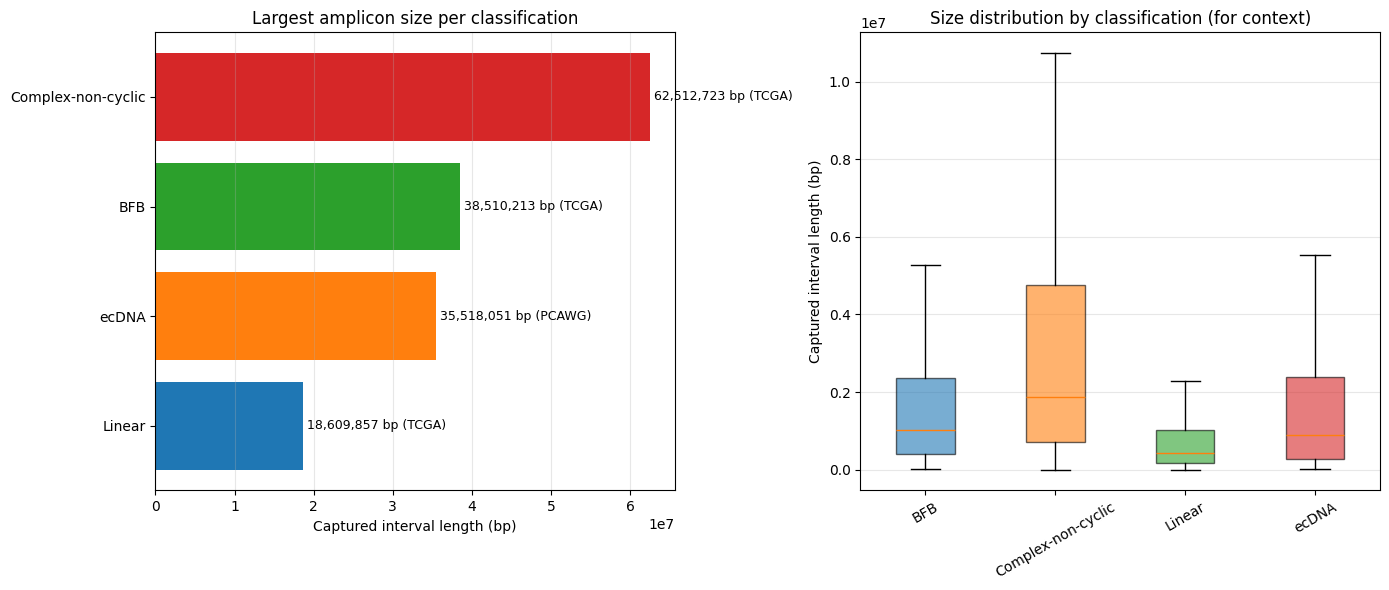

In [334]:
# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Find largest amplicon per classification
largest = (
    df_all_fixed.dropna(subset=["Captured interval length"])
    .sort_values("Captured interval length", ascending=False)
    .groupby("Classification")
    .head(1)
)

cols = ["Classification", "Dataset", "Sample name", "Tissue of origin", "Location", 
        "Captured interval length", "Feature maximum copy number", "Oncogenes"]

print(f"{'='*120}")
print("Largest amplicon (by size) per classification (all datasets):")
print(f"{'='*120}")
print(largest[cols].sort_values("Captured interval length", ascending=False).to_string(index=False))

# Additional statistics: top 3 per class
print(f"\n{'='*120}")
print("Top 3 largest amplicons per classification:")
print(f"{'='*120}")

for classification in sorted(df_all_fixed["Classification"].dropna().unique()):
    class_data = df_all_fixed[df_all_fixed["Classification"] == classification].dropna(subset=["Captured interval length"])
    top3 = class_data.nlargest(3, "Captured interval length")
    
    print(f"\n{classification} (top 3):")
    for idx, row in top3.iterrows():
        print(f"  {row['Captured interval length']:>12,.0f} bp - {row['Dataset']:6} - {row['Sample name']:30} - {row['Location']}")

# Visualization: bar chart of largest amplicon per class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart by classification
ax1 = axes[0]
largest_sorted = largest.sort_values("Captured interval length", ascending=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax1.barh(largest_sorted["Classification"], largest_sorted["Captured interval length"], 
                color=colors[:len(largest_sorted)])
ax1.set_xlabel("Captured interval length (bp)")
ax1.set_title("Largest amplicon size per classification")
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(largest_sorted.iterrows()):
    ax1.text(row["Captured interval length"], i, f' {row["Captured interval length"]:,.0f} bp ({row["Dataset"]})', 
             va='center', fontsize=9)

# Boxplot: size distribution by class (for context)
ax2 = axes[1]
classes = sorted(df_all_fixed["Classification"].dropna().unique())
data_by_class = [
    df_all_fixed[df_all_fixed["Classification"] == cls]["Captured interval length"].dropna()
    for cls in classes
]
bp = ax2.boxplot(data_by_class, labels=classes, showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(classes)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel("Captured interval length (bp)")
ax2.set_title("Size distribution by classification (for context)")
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 14) For a given gene (EGFR), list all co-amplified genes (same feature) in all datasets

In [336]:
gene = "YES1"

# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Find all co-amplified genes across all datasets
co_all = set()
features_with_gene = []

for _, r in df_all_fixed.iterrows():
    if gene in r["all_genes_list"]:
        co_all |= set(r["all_genes_list"])
        features_with_gene.append(r)

co_all.discard(gene)

print(f"{'='*80}")
print(f"Co-amplified genes with {gene} (across all datasets):")
print(f"{'='*80}")
print(f"Total co-amplified genes: {len(co_all)}")
print(f"Features containing {gene}: {len(features_with_gene)}\n")

# Display co-amplified genes
if co_all:
    sorted_genes = sorted(co_all)
    print("All co-amplified genes:")
    # Print in columns for better readability
    cols = 5
    for i in range(0, len(sorted_genes), cols):
        row_genes = sorted_genes[i:i+cols]
        print("  ".join(f"{g:15}" for g in row_genes))
else:
    print(f"No co-amplified genes found with {gene}")

# Breakdown by dataset
print(f"\n{'='*80}")
print("Co-amplified genes by dataset:")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG", "TCGA"]:
    dataset_features = df_all_fixed[df_all_fixed["Dataset"] == dataset]
    co_dataset = set()
    
    for _, r in dataset_features.iterrows():
        if gene in r["all_genes_list"]:
            co_dataset |= set(r["all_genes_list"])
    
    co_dataset.discard(gene)
    
    n_features = dataset_features["all_genes_list"].apply(lambda x: gene in x).sum()
    
    print(f"\n{dataset}:")
    print(f"  Features with {gene}: {n_features}")
    print(f"  Co-amplified genes: {len(co_dataset)}")
    if n_features > 0:
        print(f"  Top 10 co-amplified genes: {', '.join(sorted(co_dataset)[:10])}")

# Count co-occurrence frequency
print(f"\n{'='*80}")
print("Most frequent co-amplified genes (across all datasets):")
print(f"{'='*80}")

from collections import Counter
co_counts = Counter()

for _, r in df_all_fixed.iterrows():
    if gene in r["all_genes_list"]:
        genes_in_feature = set(r["all_genes_list"])
        genes_in_feature.discard(gene)
        co_counts.update(genes_in_feature)

# Top 30 most frequent
top_co = pd.DataFrame(co_counts.most_common(30), columns=["Gene", "Co-occurrence_count"])
print(top_co.to_string(index=False))

# Summary statistics by classification
print(f"\n{'='*80}")
print(f"{gene} features by classification:")
print(f"{'='*80}")

egfr_features_df = pd.DataFrame(features_with_gene)
if len(egfr_features_df) > 0:
    classification_summary = egfr_features_df.groupby(["Dataset", "Classification"]).size().reset_index(name="Count")
    print(classification_summary.to_string(index=False))
    
    # Overall by classification
    print(f"\nOverall by classification:")
    overall_class = egfr_features_df["Classification"].value_counts()
    print(overall_class)

Co-amplified genes with YES1 (across all datasets):
Total co-amplified genes: 50
Features containing YES1: 9

All co-amplified genes:
ABHD3            ADCYAP1          ANKRD29          C18orf2          C18orf45       
C18orf56         C18orf8          CABLES1          CABYR            CBX3P2         
CETN1            CLUL1            COLEC12          CTAGE1           DLGAP1         
DLGAP1-AS1       DLGAP1-AS2       DLGAP1-AS3       DLGAP1-AS4       DLGAP1-AS5     
EMILIN2          ENOSF1           ESCO1            FAM38B           FLJ35776       
GAPLINC          GATA6            HRH4             IMPACT           LAMA3          
LPIN2            METTL4           MIB1             MYL12A           MYL12B         
MYOM1            NDC80            NPC1             OSBPL1A          RBBP8          
RIOK3            ROCK1P1          SMCHD1           SNRPD1           TGIF1          
THOC1            TTC39C           TYMS             TYMSOS           USP14          

Co-amplified genes by dat

# 15) Which genes are exclusive to ecDNA (never BFB or Linear)? (all datasets)

In [337]:
from collections import defaultdict

# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Track which classifications each gene appears in
gene_cls = defaultdict(set)

for _, r in df_all_fixed.iterrows():
    for g in r["oncogenes_list"]:
        gene_cls[g].add(r["Classification"])

# Find genes exclusive to ecDNA (never in BFB or Linear)
exclusive = sorted([g for g, c in gene_cls.items() if c == {"ecDNA"}])

print(f"{'='*80}")
print("Genes exclusive to ecDNA (never BFB or Linear) - all datasets:")
print(f"{'='*80}")
print(f"Total count: {len(exclusive)}\n")

if exclusive:
    # Display in columns for better readability
    cols = 5
    for i in range(0, len(exclusive), cols):
        row_genes = exclusive[i:i+cols]
        print("  ".join(f"{g:15}" for g in row_genes))
else:
    print("No ecDNA-exclusive genes found")

# Breakdown by dataset
print(f"\n{'='*80}")
print("Breakdown by dataset:")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG", "TCGA"]:
    df_dataset = df_all_fixed[df_all_fixed["Dataset"] == dataset]
    
    gene_cls_ds = defaultdict(set)
    for _, r in df_dataset.iterrows():
        for g in r["oncogenes_list"]:
            gene_cls_ds[g].add(r["Classification"])
    
    exclusive_ds = sorted([g for g, c in gene_cls_ds.items() if c == {"ecDNA"}])
    print(f"\n{dataset}: {len(exclusive_ds)} ecDNA-exclusive genes")
    if len(exclusive_ds) > 0 and len(exclusive_ds) <= 20:
        print(f"  Genes: {', '.join(exclusive_ds)}")
    elif len(exclusive_ds) > 20:
        print(f"  First 20: {', '.join(exclusive_ds[:20])}")

# Show frequency of ecDNA-exclusive genes
print(f"\n{'='*80}")
print("Top 20 ecDNA-exclusive genes by feature count:")
print(f"{'='*80}")

from collections import Counter
exclusive_counts = Counter()

for _, r in df_all_fixed[df_all_fixed["Classification"] == "ecDNA"].iterrows():
    for g in set(r["oncogenes_list"]):
        if g in exclusive:
            exclusive_counts[g] += 1

top_exclusive = pd.DataFrame(exclusive_counts.most_common(20), columns=["Gene", "ecDNA_feature_count"])
print(top_exclusive.to_string(index=False))

Genes exclusive to ecDNA (never BFB or Linear) - all datasets:
Total count: 56

AFF1             AKTIP            ALDH2            ARAF             ASCL1          
ATM              BCL7A            BMI1             BMPR1A           BTG1           
CAD              CD24             CDKN2C           CTNNB1           DDX10          
DICER1           DUSP26           EBF1             EIF3E            ELK1           
ELK3             FH               GNAI2            GOPC             HMGN5          
HSPA5            KMT2A            KSR2             LCN2             LMX1B          
MAFB             MRAS             NOTCH4           PAK7             POU2AF1        
PRDM9            PTPN11           RAD51B           RASSF1           RET            
RGR              RMI2             RNF217-AS1       SART3            SLC34A2        
SUFU             TCL1A            TCL1B            TCL6             TLE1           
TRIB2            TRIM8            UBE3C            VTI1A            WAPAL       

# 16) Which chromosomes are most frequently amplified? (all datasets)

Most frequently amplified chromosomes (all datasets):
Location
chr1     122
chr8     104
chr11    101
chr3      77
chr12     74
chr6      62
chr17     62
chr7      55
chr2      54
chr20     48
chr5      44
chr14     42
chr19     38
chr16     34
chrX      34
chr4      33
chr9      31
chr10     31
chr22     29
chr18     25
chr13     24
chr15     21
chr21     11
Name: count, dtype: int64

Chromosome amplification by dataset:

CCLE (top 10):
Location
chr1     122
chr8     104
chr11    101
chr3      77
chr12     74
chr6      62
chr17     62
chr7      55
chr2      54
chr20     48
Name: count, dtype: int64

PCAWG (top 10):
Series([], Name: count, dtype: int64)

TCGA (top 10):
Series([], Name: count, dtype: int64)

Chromosome counts by dataset (top 15 chromosomes):
Dataset   CCLE
Location      
chr1       122
chr8       104
chr11      101
chr3        77
chr12       74
chr6        62
chr17       62
chr7        55
chr2        54
chr20       48
chr5        44
chr14       42
chr19       38
chr16  

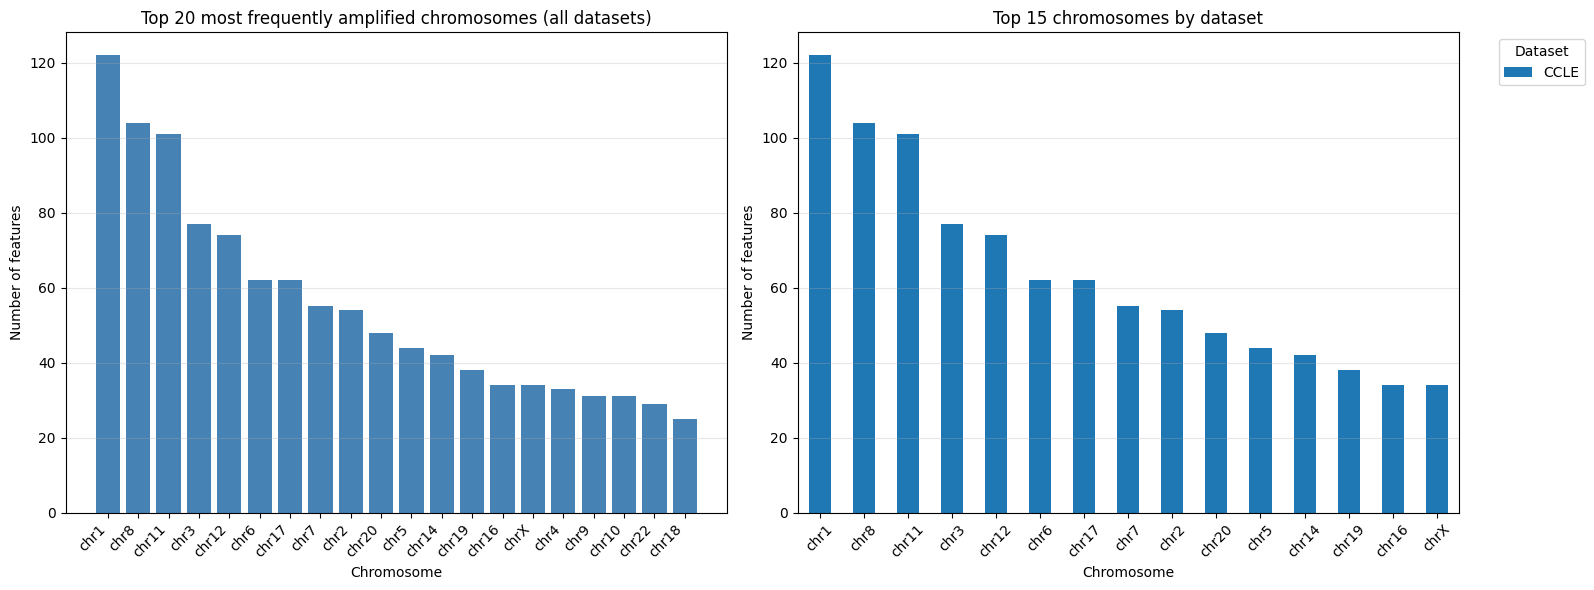


Chromosome distribution by classification (top 10 chromosomes):
Classification  BFB  Complex-non-cyclic  Linear  ecDNA
Location                                              
chr1             12                  20      61     29
chr8              8                  12      38     46
chr11            15                  22      38     26
chr3              6                  11      37     23
chr12             7                  12      28     27
chr6              5                   9      37     11
chr17             6                  14      26     16
chr7              7                  10      22     16
chr2              3                   2      41      8
chr20             3                  15      20     10


In [338]:
# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Extract chromosome from Location column
chroms_all = (
    df_all_fixed["Location"]
    .str.extract(r"(chr\d+|chrX|chrY)", expand=False)
)

# Overall chromosome counts
chrom_counts_all = chroms_all.value_counts()

print(f"{'='*80}")
print("Most frequently amplified chromosomes (all datasets):")
print(f"{'='*80}")
print(chrom_counts_all)

# Breakdown by dataset
print(f"\n{'='*80}")
print("Chromosome amplification by dataset:")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG", "TCGA"]:
    df_dataset = df_all_fixed[df_all_fixed["Dataset"] == dataset]
    chroms_dataset = df_dataset["Location"].str.extract(r"(chr\d+|chrX|chrY)", expand=False)
    chrom_counts_dataset = chroms_dataset.value_counts()
    
    print(f"\n{dataset} (top 10):")
    print(chrom_counts_dataset.head(10))

# Crosstab: chromosome by dataset
df_all_fixed["Chromosome"] = chroms_all
chrom_dataset_tab = pd.crosstab(df_all_fixed["Chromosome"], df_all_fixed["Dataset"]).fillna(0)

print(f"\n{'='*80}")
print("Chromosome counts by dataset (top 15 chromosomes):")
print(f"{'='*80}")
top_chroms = chrom_counts_all.head(15).index
print(chrom_dataset_tab.loc[top_chroms])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: overall chromosome frequency
ax1 = axes[0]
top_chroms_plot = chrom_counts_all.head(20)
ax1.bar(range(len(top_chroms_plot)), top_chroms_plot.values, color='steelblue')
ax1.set_xticks(range(len(top_chroms_plot)))
ax1.set_xticklabels(top_chroms_plot.index, rotation=45, ha='right')
ax1.set_ylabel("Number of features")
ax1.set_xlabel("Chromosome")
ax1.set_title("Top 20 most frequently amplified chromosomes (all datasets)")
ax1.grid(axis='y', alpha=0.3)

# Stacked bar chart: chromosome by dataset
ax2 = axes[1]
chrom_dataset_tab.loc[top_chroms_plot.head(15).index].plot(
    kind='bar', 
    stacked=True, 
    ax=ax2,
    color=['#1f77b4', '#ff7f0e', '#2ca02c']
)
ax2.set_ylabel("Number of features")
ax2.set_xlabel("Chromosome")
ax2.set_title("Top 15 chromosomes by dataset")
ax2.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: by classification
print(f"\n{'='*80}")
print("Chromosome distribution by classification (top 10 chromosomes):")
print(f"{'='*80}")

chrom_class_tab = pd.crosstab(df_all_fixed["Chromosome"], df_all_fixed["Classification"]).fillna(0)
print(chrom_class_tab.loc[top_chroms_plot.head(10).index])

# 17) Which oncogenes are most recurrent across unique samples (any class) in all datasets?

Top 40 oncogenes by unique sample count (all datasets):
Gene
CTTN        161
CCND1       158
FGF4        154
FGF3        149
ERBB2       130
EGFR        129
MDM2        123
C17orf37    113
YEATS4      102
CCNE1        95
MYC          86
CDK4         86
C19orf2      86
AGAP2        81
PVT1         79
CDK12        75
IFNG         73
FGFR1        72
LSM1         67
DDHD2        67
WHSC1L1      66
ADAM9        66
CSF3         63
THRA         58
PAK1         57
BRF2         57
RSF1         56
GAB2         55
HMGA2        55
INTS4        54
KRAS         54
ZNF703       54
MYST3        53
TBC1D15      47
YAP1         44
CDC6         44
SDHC         43
RARA         42
BIRC2        40
BIRC3        40
Name: Sample, dtype: int64

Top 30 oncogenes per dataset:

CCLE (top 30):
Gene
PVT1      33
MYC       33
CTTN      23
FGF4      23
CCND1     23
FGF3      23
MIEN1     19
ERBB2     19
MYCL      17
CDK12     15
KDM2A     12
URI1      11
KRAS      11
MECOM     10
CRKL      10
MUC4       9
FGFR1      8

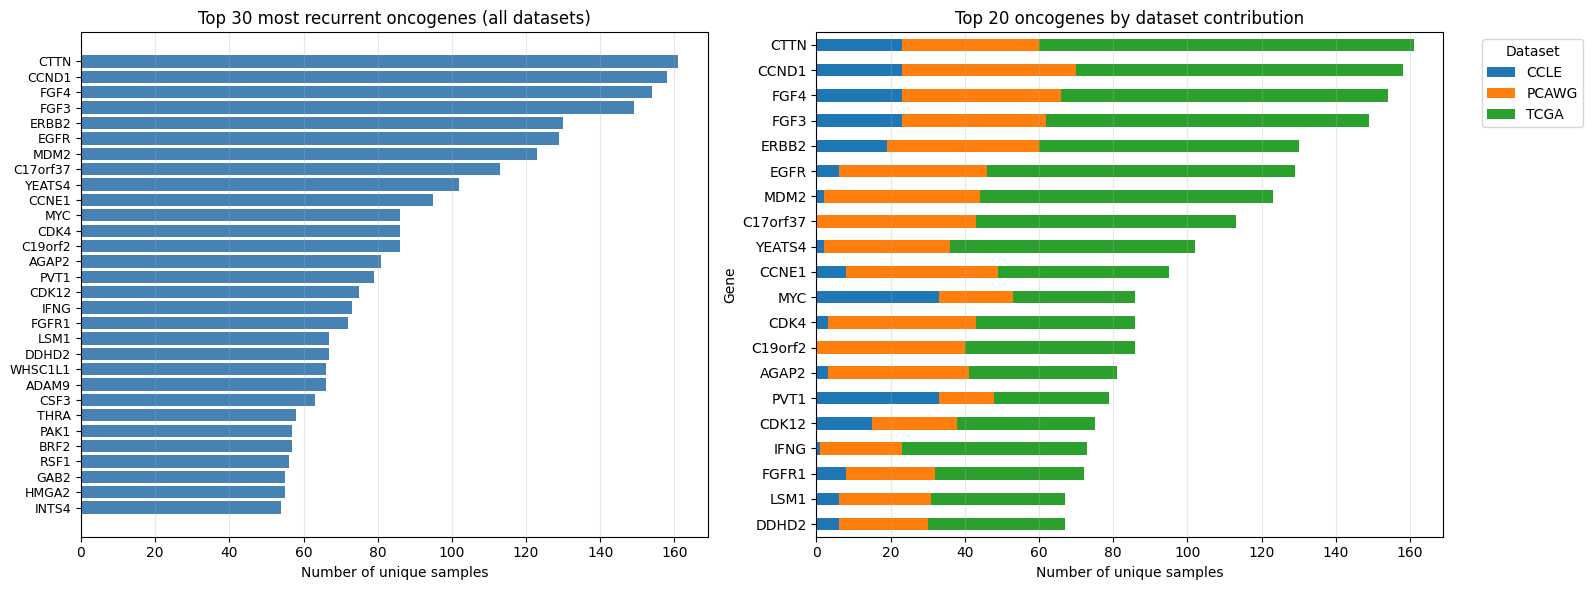

In [339]:
# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Create pairs of (gene, sample) to track unique sample occurrences
pairs = []
for _, r in df_all_fixed.iterrows():
    for g in set(r["oncogenes_list"]):
        pairs.append((g, r["Sample name"], r["Dataset"]))

pairs_df = pd.DataFrame(pairs, columns=["Gene", "Sample", "Dataset"])

# Count unique samples per gene (across all datasets)
top_genes_all = (
    pairs_df.drop_duplicates(subset=["Gene", "Sample"])
    .groupby("Gene")["Sample"]
    .nunique()
    .sort_values(ascending=False)
)

print(f"{'='*80}")
print("Top 40 oncogenes by unique sample count (all datasets):")
print(f"{'='*80}")
print(top_genes_all.head(40))

# Breakdown by dataset
print(f"\n{'='*80}")
print("Top 30 oncogenes per dataset:")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG", "TCGA"]:
    dataset_pairs = pairs_df[pairs_df["Dataset"] == dataset]
    top_dataset = (
        dataset_pairs.drop_duplicates(subset=["Gene", "Sample"])
        .groupby("Gene")["Sample"]
        .nunique()
        .sort_values(ascending=False)
    )
    
    print(f"\n{dataset} (top 30):")
    print(top_dataset.head(30))

# Show detailed breakdown for top 20 genes
print(f"\n{'='*80}")
print("Dataset breakdown for top 20 oncogenes:")
print(f"{'='*80}")

top_20_genes = top_genes_all.head(20).index

dataset_breakdown = []
for gene in top_20_genes:
    gene_pairs = pairs_df[pairs_df["Gene"] == gene]
    
    total_samples = gene_pairs["Sample"].nunique()
    ccle_samples = gene_pairs[gene_pairs["Dataset"] == "CCLE"]["Sample"].nunique()
    pcawg_samples = gene_pairs[gene_pairs["Dataset"] == "PCAWG"]["Sample"].nunique()
    tcga_samples = gene_pairs[gene_pairs["Dataset"] == "TCGA"]["Sample"].nunique()
    
    dataset_breakdown.append({
        "Gene": gene,
        "Total_samples": total_samples,
        "CCLE": ccle_samples,
        "PCAWG": pcawg_samples,
        "TCGA": tcga_samples
    })

breakdown_df = pd.DataFrame(dataset_breakdown)
print(breakdown_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: top 30 oncogenes overall
ax1 = axes[0]
top_30 = top_genes_all.head(30)
ax1.barh(range(len(top_30)), top_30.values, color='steelblue')
ax1.set_yticks(range(len(top_30)))
ax1.set_yticklabels(top_30.index, fontsize=9)
ax1.set_xlabel("Number of unique samples")
ax1.set_title("Top 30 most recurrent oncogenes (all datasets)")
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Stacked bar chart: top 20 by dataset
ax2 = axes[1]
breakdown_df_top20 = breakdown_df.set_index("Gene")
breakdown_df_top20[["CCLE", "PCAWG", "TCGA"]].plot(
    kind='barh',
    stacked=True,
    ax=ax2,
    color=['#1f77b4', '#ff7f0e', '#2ca02c']
)
ax2.set_xlabel("Number of unique samples")
ax2.set_title("Top 20 oncogenes by dataset contribution")
ax2.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 18) Among samples with ecDNA, what are the most common co-amplified oncogene pairs? (all datasets)

Total ecDNA features across all datasets: 1777
Dataset breakdown:
Dataset
TCGA     766
PCAWG    714
CCLE     297
Name: count, dtype: int64

Top 40 most common co-amplified oncogene pairs in ecDNA (all datasets):
   Gene1   Gene2  ecDNA_feature_count
   AGAP2    CDK4                   64
    MDM2  YEATS4                   62
C17orf37   ERBB2                   54
     MYC    PVT1                   50
    IFNG    MDM2                   42
    CDK4    MDM2                   42
    IFNG  YEATS4                   41
   AGAP2    MDM2                   40
   HMGA2    MDM2                   33
   HMGA2  YEATS4                   31
    CDK4  YEATS4                   30
   AGAP2  YEATS4                   29
    CDK4   DDIT3                   27
    FGF3    FGF4                   26
   CDK12   ERBB2                   25
    GAB2   INTS4                   25
   AGAP2   DDIT3                   25
   INTS4    RSF1                   24
    CDK4   HMGA2                   24
   CCND1    FGF4            

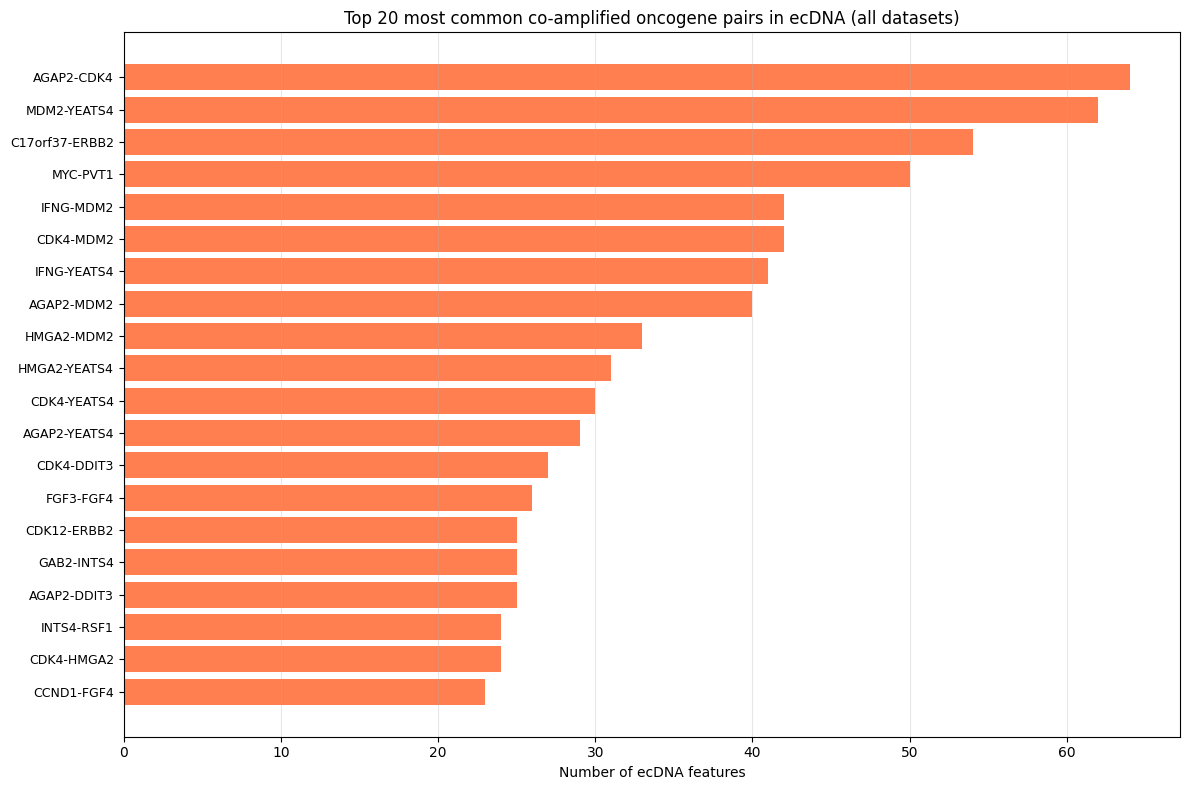

In [340]:
from itertools import combinations
from collections import Counter

# Standardize classification names
df_all_fixed = df_all.copy()
df_all_fixed["Classification"] = df_all_fixed["Classification"].replace({
    "Complex non-cyclic": "Complex-non-cyclic",
    "Linear amplification": "Linear"
})

# Filter for ecDNA features only
ec_all = df_all_fixed[df_all_fixed["Classification"] == "ecDNA"]

print(f"{'='*80}")
print(f"Total ecDNA features across all datasets: {len(ec_all)}")
print(f"Dataset breakdown:")
print(ec_all["Dataset"].value_counts())
print(f"{'='*80}")

# Count co-amplified oncogene pairs
pair_ctr = Counter()
for xs in ec_all["oncogenes_list"]:
    genes = sorted(set(xs))
    if len(genes) >= 2:
        for a, b in combinations(genes, 2):
            pair_ctr[(a, b)] += 1

# Create DataFrame of top pairs
top_pairs = pd.DataFrame(
    [(*k, v) for k, v in pair_ctr.most_common(40)],
    columns=["Gene1", "Gene2", "ecDNA_feature_count"]
)

print(f"\n{'='*80}")
print("Top 40 most common co-amplified oncogene pairs in ecDNA (all datasets):")
print(f"{'='*80}")
print(top_pairs.to_string(index=False))

# Breakdown by dataset
print(f"\n{'='*80}")
print("Co-amplified pairs by dataset (top 20 each):")
print(f"{'='*80}")

for dataset in ["CCLE", "PCAWG", "TCGA"]:
    ec_dataset = ec_all[ec_all["Dataset"] == dataset]
    
    pair_ctr_ds = Counter()
    for xs in ec_dataset["oncogenes_list"]:
        genes = sorted(set(xs))
        if len(genes) >= 2:
            for a, b in combinations(genes, 2):
                pair_ctr_ds[(a, b)] += 1
    
    print(f"\n{dataset} ({len(ec_dataset)} ecDNA features):")
    if len(pair_ctr_ds) > 0:
        top_pairs_ds = pd.DataFrame(
            [(*k, v) for k, v in pair_ctr_ds.most_common(20)],
            columns=["Gene1", "Gene2", "Count"]
        )
        print(top_pairs_ds.to_string(index=False))
    else:
        print("  No co-amplified pairs found")

# Dataset contribution for top 10 pairs
print(f"\n{'='*80}")
print("Dataset contribution for top 10 pairs:")
print(f"{'='*80}")

top_10_pairs = [tuple(row[["Gene1", "Gene2"]]) for _, row in top_pairs.head(10).iterrows()]

pair_dataset_breakdown = []
for gene1, gene2 in top_10_pairs:
    total = pair_ctr[(gene1, gene2)]
    
    # Count in each dataset
    ccle_count = 0
    pcawg_count = 0
    tcga_count = 0
    
    for dataset, df_subset in [("CCLE", ec_all[ec_all["Dataset"] == "CCLE"]),
                               ("PCAWG", ec_all[ec_all["Dataset"] == "PCAWG"]),
                               ("TCGA", ec_all[ec_all["Dataset"] == "TCGA"])]:
        for xs in df_subset["oncogenes_list"]:
            genes_set = set(xs)
            if gene1 in genes_set and gene2 in genes_set:
                if dataset == "CCLE":
                    ccle_count += 1
                elif dataset == "PCAWG":
                    pcawg_count += 1
                elif dataset == "TCGA":
                    tcga_count += 1
    
    pair_dataset_breakdown.append({
        "Pair": f"{gene1}-{gene2}",
        "Total": total,
        "CCLE": ccle_count,
        "PCAWG": pcawg_count,
        "TCGA": tcga_count
    })

breakdown_pairs_df = pd.DataFrame(pair_dataset_breakdown)
print(breakdown_pairs_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 8))

top_20_pairs = top_pairs.head(20)
pair_labels = [f"{row['Gene1']}-{row['Gene2']}" for _, row in top_20_pairs.iterrows()]

plt.barh(range(len(top_20_pairs)), top_20_pairs["ecDNA_feature_count"], color='coral')
plt.yticks(range(len(top_20_pairs)), pair_labels, fontsize=9)
plt.xlabel("Number of ecDNA features")
plt.title("Top 20 most common co-amplified oncogene pairs in ecDNA (all datasets)")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()